# TFM — Modelos predictivos sobre comportamiento de compra en easyMoney

## Parte 4. Modelización predictiva a partir de variables sociodemográficas, comerciales y de contratación

Este notebook desarrolla la fase de **preparación analítica y modelización predictiva** del proyecto. El objetivo es construir un dataset integrado a nivel cliente-periodo y utilizarlo para anticipar distintos comportamientos de contratación mediante técnicas supervisadas.

En concreto, se plantean tres niveles de predicción:

1. **Probabilidad de realizar cualquier compra en el siguiente mes**.  
2. **Probabilidad de contratar una familia de productos**.  
3. **Probabilidad de contratar un producto concreto**.  

El flujo de trabajo sigue una lógica progresiva: carga de fuentes, integración, análisis del dato, limpieza, construcción del dataset final, generación de variables explicativas y entrenamiento de modelos con validación temporal.


## Índice del notebook

1. [Contexto técnico y librerías](#1-contexto-técnico-y-librerías)  
2. [Carga de datos](#2-carga-de-datos)  
3. [Integración inicial de fuentes](#3-integración-inicial-de-fuentes)  
4. [Comprensión y diagnóstico del dato](#4-comprensión-y-diagnóstico-del-dato)  
5. [Limpieza de datos e imputación de nulos](#5-limpieza-de-datos-e-imputación-de-nulos)  
6. [Construcción del dataset analítico final](#6-construcción-del-dataset-analítico-final)  
7. [Feature engineering](#7-feature-engineering)  
   - 7.1 [Predicción de cualquier compra](#71-predicción-de-cualquier-compra)  
   - 7.2 [Predicción por familia de producto](#72-predicción-por-familia-de-producto)  
   - 7.3 [Predicción de producto específico](#73-predicción-de-producto-específico)  
8. [Modelos predictivos](#8-modelos-predictivos)  
   - 8.1 [Modelo para cualquier compra](#81-modelo-para-cualquier-compra)  
   - 8.2 [Modelo para familias contratadas](#82-modelo-para-familias-contratadas)  
   - 8.3 [Modelo para productos concretos](#83-modelo-para-productos-concretos)  
9. [Lectura analítica final](#9-lectura-analítica-final)  


## 1. Contexto técnico y librerías

En este primer bloque se prepara el entorno de trabajo y se cargan las librerías necesarias para el análisis.  
Se incluyen paquetes para:

- manipulación de datos,
- visualización,
- transformación de variables,
- construcción de pipelines,
- y entrenamiento de modelos basados en **LightGBM**.

> **Nota:** algunas celdas de instalación están pensadas para ejecución en Google Colab. Se mantienen para garantizar la reproducibilidad del entorno original del proyecto.


In [ ]:
# Me niego a usar NumPy <2.x en un entorno virtual

!pip install --upgrade \
    "numpy==2.0.2" \
    "pandas==2.2.2" \
    "scipy==1.17.1" \
    "matplotlib>=3.10.8" \
    "scikit-learn==1.8.0" \
    "seaborn==0.13.2" \
    "jedi==0.19.2" \
    "pillow==11.0.0"\
    "setuptools==70.0.0"\
    --force-reinstall

!pip install "dython>=0.7.12" --no-deps

  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pillow-11.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached setuptools-70.0.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2

  Using cached dython-0.7.12-py3-none-any.whl.metadata (3.4 kB)
Using cached dython-0.7.12-py3-none-any.whl (26 kB)
  Attempting uninstall: dython
    Found existing installation: dython 0.7.10
    Uninstalling dython-0.7.10:
      Successfully uninstalled dython-0.7.10


In [1]:
# 3. Reiniciar de nuevo el runtime (obligatorio tras cambiar NumPy/Pandas)

# 4. Ahora importar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV

from lightgbm import LGBMClassifier

from dython.nominal import associations, numerical_encoding

## 2. Carga de datos

Se cargan las distintas fuentes utilizadas en esta parte del TFM:

- **customer_sociodemographics**: variables demográficas y geográficas del cliente,
- **customer_commercial_activity**: información de actividad comercial y relación con la entidad,
- **customer_products**: histórico de productos contratados,
- **product_description**: catálogo maestro de productos,
- **sales**: operaciones comerciales registradas.

Además, se reutilizan datasets intermedios ya depurados en fases previas del proyecto para acelerar la construcción del dataset analítico final.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df_socio= pd.read_csv('/content/drive/MyDrive/TFM/Datasets/customer_sociodemographics.csv')
df_comm= pd.read_csv('/content/drive/MyDrive/TFM/Datasets/customer_commercial_activity.csv')
df_prod= pd.read_csv('/content/drive/MyDrive/TFM/Datasets/customer_products.csv')
df_prod_desc= pd.read_csv('/content/drive/MyDrive/TFM/Datasets/product_description.csv')
df_sales= pd.read_csv('/content/drive/MyDrive/TFM/Datasets/sales.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1. Cargar los datasets
df_prod = pd.read_csv("../DatasetsTFM/customer_products.csv")
df_socio = pd.read_csv("../DatasetsTFM/customer_sociodemographics.csv")
df_comm = pd.read_csv("../DatasetsTFM/customer_commercial_activity.csv")
df_sales = pd.read_csv("../DatasetsTFM/sales.csv")
df_prod_desc = pd.read_csv("../DatasetsTFM/product_description.csv")

In [2]:
df_master = pd.read_csv("../DatasetsTFM/df_master_limpio.csv")
df_ventas = pd.read_csv("../DatasetsTFM/df_ventas_enriquecida.csv")

In [ ]:
df_prod_desc = pd.read_csv("../DatasetsTFM/product_description.csv")

,Unnamed: 0,pk_product_ID,product_desc,family_product
0,0,4657,em_acount,account
1,1,3819,debit_card,payment_card
2,2,1364,pension_plan,pension_plan
3,3,2234,payroll,account
4,4,2235,payroll_account,account
5,5,8871,emc_account,account
6,6,2312,credit_card,payment_card
7,7,2335,short_term_deposit,investment
8,8,2336,long_term_deposit,investment
9,9,2673,securities,investment


In [44]:
print(df_prod_desc.head(15))

    Unnamed: 0  pk_product_ID        product_desc family_product
0            0           4657           em_acount        account
1            1           3819          debit_card   payment_card
2            2           1364        pension_plan   pension_plan
3            3           2234             payroll        account
4            4           2235     payroll_account        account
5            5           8871         emc_account        account
6            6           2312         credit_card   payment_card
7            7           2335  short_term_deposit     investment
8            8           2336   long_term_deposit     investment
9            9           2673          securities     investment
10          10           1119               funds     investment
11          11           9001               loans           loan
12          12           4033            mortgage           loan


In [42]:
df_ventas.head()

,pk_sale,cid,month_sale,product_ID,net_margin,pk_product_ID,product_desc,family_product,month_sale_join
0,6666,33620,2018-05-01,2335,952.9,2335,short_term_deposit,investment,2018-05
1,6667,35063,2018-06-01,2335,1625.2,2335,short_term_deposit,investment,2018-06
2,6668,37299,2018-02-01,2335,1279.7,2335,short_term_deposit,investment,2018-02
3,6669,39997,2018-02-01,2335,1511.9,2335,short_term_deposit,investment,2018-02
4,6670,44012,2018-02-01,2335,1680.3,2335,short_term_deposit,investment,2018-02


## 3. Integración inicial de fuentes

En este bloque se realiza la primera consolidación de tablas. El objetivo es:

- eliminar columnas residuales o de carga,
- enriquecer el histórico de ventas con la descripción del producto,
- y construir una vista maestra con mayor capacidad explicativa.

Esta integración permite pasar de varias fuentes aisladas a una base coherente sobre la que realizar diagnóstico, limpieza y modelización.


In [3]:
def limpiar_columnas_basura(df):
    cols_to_drop = [c for c in df.columns if 'Unnamed' in c]
    if cols_to_drop:
        print(f"🗑️ Eliminando columnas basura: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
    return df

df_prod = limpiar_columnas_basura(df_prod)
df_socio = limpiar_columnas_basura(df_socio)
df_comm = limpiar_columnas_basura(df_comm)
df_sales = limpiar_columnas_basura(df_sales)
df_prod_desc = limpiar_columnas_basura(df_prod_desc)

🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']


In [5]:
# SQL Equivalente:
# SELECT s.*, d.product_desc
# FROM sales s
# LEFT JOIN product_description d ON s.product_ID = d.pk_product_ID;

# En Pandas:
df_ventas_enriquecida = pd.merge(
    df_sales,
    df_prod_desc,
    left_on='product_ID',
    right_on='pk_product_ID',
    how='left'
)

In [6]:
# SQL Equivalente:
# SELECT * FROM sociodemo s
# JOIN commercial c ON s.pk_cid = c.pk_cid AND s.pk_partition = c.pk_partition

# En Pandas:
df_master = pd.merge(
    df_socio,
    df_comm,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)

In [7]:
# Fusionamos df_prod al df_master que ya tienes
df_master = pd.merge(
    df_master,
    df_prod,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)

## 4. Comprensión y diagnóstico del dato

Antes de transformar o modelizar, se analiza la estructura del dataset resultante para identificar:

- distribución de variables,
- posibles incoherencias temporales,
- cardinalidad de atributos relevantes,
- concentración o dispersión en determinadas categorías,
- y primeras señales sobre calidad del dato.

Este bloque cumple una función metodológica importante: justificar las decisiones posteriores de imputación, recodificación y selección de variables.


In [ ]:
# Agrupamos por cliente y contamos cuántos salarios DIFERENTES ha tenido
# dropna=False es importante: cuenta cambiar de NaN a un valor numérico como un cambio
conteo_cambios = df_socio.groupby('pk_cid')['salary'].nunique(dropna=False)

# Filtramos solo los que tienen más de 1 valor distinto
clientes_con_cambios = conteo_cambios[conteo_cambios > 1]

print(f"Hay {len(clientes_con_cambios)} clientes que han cambiado de salario (o de NaN a dato).")

# Cogemos, por ejemplo, los primeros 5 clientes que sabemos que han cambiado
ids_ejemplo = clientes_con_cambios.head(5).index

# Filtramos el dataframe original solo con esos IDs y ordenamos para ver la historia
historial_cambios = df_socio[df_socio['pk_cid'].isin(ids_ejemplo)].sort_values(['pk_cid', 'pk_partition'])

# Mostramos las columnas relevantes
cols_interes = ['pk_cid', 'pk_partition', 'salary']
historial_cambios[cols_interes]

conteo_cambios = df_comm.groupby('pk_cid')['segment'].nunique(dropna=False)

# Filtramos solo los que tienen más de 1 valor distinto
clientes_con_cambios = conteo_cambios[conteo_cambios > 1]

print(f"Hay {len(clientes_con_cambios)} clientes que han cambiado de segmento (o de NaN a dato).")

Hay 65 clientes que han cambiado de salario (o de NaN a dato).
Hay 130295 clientes que han cambiado de segmento (o de NaN a dato).


In [ ]:
# 1. Definimos la lista de productos (basada en las columnas de tu df_prod)
productos = [
    'short_term_deposit', 'loans', 'mortgage', 'funds', 'securities',
    'long_term_deposit', 'em_account_pp', 'credit_card', 'payroll',
    'pension_plan', 'payroll_account', 'emc_account', 'debit_card',
    'em_account_p', 'em_acount'
]

# 2. Iteramos sobre cada producto para ver los cambios
print("--- Clientes con cambios (contrataciones o cancelaciones) por producto ---")

for prod in productos:
    # Contamos cuántos valores DIFERENTES (0, 1 o NaN) ha tenido cada cliente en ese producto
    conteo_cambios = df_master.groupby('pk_cid')[prod].nunique(dropna=False)

    # Filtramos los que tienen más de 1 valor distinto
    clientes_con_cambios = conteo_cambios[conteo_cambios > 1]

    # Mostramos el resultado
    print(f"{prod}: {len(clientes_con_cambios)} clientes han cambiado de estado.")

--- Clientes con cambios (contrataciones o cancelaciones) por producto ---
short_term_deposit: 5322 clientes han cambiado de estado.
loans: 32 clientes han cambiado de estado.
mortgage: 12 clientes han cambiado de estado.
funds: 1054 clientes han cambiado de estado.
securities: 1299 clientes han cambiado de estado.
long_term_deposit: 6468 clientes han cambiado de estado.
em_account_pp: 0 clientes han cambiado de estado.
credit_card: 7137 clientes han cambiado de estado.
payroll: 23971 clientes han cambiado de estado.
pension_plan: 25218 clientes han cambiado de estado.
payroll_account: 22193 clientes han cambiado de estado.
emc_account: 14570 clientes han cambiado de estado.
debit_card: 48674 clientes han cambiado de estado.
em_account_p: 0 clientes han cambiado de estado.
em_acount: 64623 clientes han cambiado de estado.


In [ ]:
# 1. Ordenar por cliente y por fecha para que la línea temporal sea correcta
df_master_sorted = df_master.sort_values(by=['pk_cid', 'pk_partition'])

print("--- Altas (Contrataciones) y Bajas (Cancelaciones) por producto ---")

for prod in productos:
    # 2. Calculamos la diferencia mes a mes para cada cliente de forma aislada
    # .diff() resta la fila actual menos la fila anterior
    cambios_mes = df_master_sorted.groupby('pk_cid')[prod].diff()

    # 3. Filtramos y contamos
    altas = (cambios_mes == 1).sum()   # Pasó de 0 a 1
    bajas = (cambios_mes == -1).sum()  # Pasó de 1 a 0

    # Imprimimos el resultado tabulado para que sea fácil de leer
    print(f"{prod:<20} | Altas: {altas:<6} | Bajas: {bajas:<6}")

In [ ]:
for prod in productos:
    # 2. Calculamos la diferencia mes a mes para cada cliente de forma aislada
    # .diff() resta la fila actual menos la fila anterior
    cambios_mes = df_master_sorted.groupby('pk_cid')[prod].diff()

    target_name = f'target_{prod}'
    df_master[target_name] = (cambios_mes == 1).astype(int)

In [ ]:
#1. Preparamos test
df_master_sorted_t = df_master_sorted.copy()

# 2. AGRUPAMOS Y CALCULAMOS (Aquí es donde el objeto GroupBy se convierte en números)
# Calculamos la diferencia del mes actual vs el anterior para este producto
cambio_em_acount = df_master_sorted_t.groupby('pk_cid')['em_acount'].diff()

# 3. CREAMOS EL TARGET (Variable objetivo para el modelo)
# Si la diferencia es 1, significa que pasó de 0 a 1 (¡Contratación!)
# Llenamos los nulos (el primer mes de cada cliente) con 0
df_master_sorted_t['target_em_acount'] = (cambio_em_acount == 1).astype(int)

# Comprobación de que ahora tienes una columna limpia de 0s y 1s:
print(df_master_sorted_t[['pk_cid', 'pk_partition', 'em_acount', 'target_em_acount']].head(10))

         pk_cid pk_partition  em_acount  target_em_acount
1479563   15891      2018-07          1                 0
2168122   15891      2018-08          0                 0
2962973   16063      2018-11          0                 0
3628236   16063      2018-12          0                 0
4028169   16063      2019-01          0                 0
4480637   16063      2019-02          0                 0
4876040   16063      2019-03          0                 0
5134317   16063      2019-04          0                 0
5523397   16063      2019-05          0                 0
3628238   16203      2018-12          0                 0


In [ ]:
print(df_master_sorted_t[['pk_cid', 'pk_partition', 'em_acount', 'target_em_acount']].head(20))

         pk_cid pk_partition  em_acount  target_em_acount
1479563   15891      2018-07          1                 0
2168122   15891      2018-08          0                 0
2962973   16063      2018-11          0                 0
3628236   16063      2018-12          0                 0
4028169   16063      2019-01          0                 0
4480637   16063      2019-02          0                 0
4876040   16063      2019-03          0                 0
5134317   16063      2019-04          0                 0
5523397   16063      2019-05          0                 0
3628238   16203      2018-12          0                 0
4028170   16203      2019-01          1                 1
4480636   16203      2019-02          1                 0
4876039   16203      2019-03          1                 0
5134321   16203      2019-04          1                 0
5523396   16203      2019-05          1                 0
2171490   16502      2018-09          0                 0
2943633   1650

In [ ]:
df_master_sorted_t[df_master_sorted_t['target_em_acount']==1]

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,target_em_acount
4028170,16203,2019-01,ES,8.0,V,70,N,NaN,2018-12,KAT,...,0,0,0.0,0.0,0,0,0,0,1,1
2943633,16502,2018-10,ES,28.0,H,58,N,NaN,2018-09,KHN,...,0,0,0.0,0.0,0,0,0,0,1,1
3628254,21719,2018-12,ES,28.0,H,56,N,97573.38,2018-04,KAT,...,0,0,0.0,0.0,0,0,1,0,1,1
4876022,24763,2019-03,ES,39.0,H,66,N,NaN,2019-02,KHM,...,0,0,0.0,0.0,0,0,0,0,1,1
2943644,29484,2018-10,ES,28.0,H,51,N,159038.19,2015-03,KAT,...,0,0,0.0,0.0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5682996,1548196,2019-05,ES,12.0,H,32,N,NaN,2019-04,KHM,...,0,0,0.0,0.0,0,0,1,0,1,1
5683007,1548197,2019-05,ES,29.0,V,40,N,NaN,2019-04,KHM,...,0,0,1.0,1.0,0,0,1,0,1,1
5682993,1548201,2019-05,ES,28.0,H,36,N,NaN,2019-04,KHM,...,0,0,0.0,0.0,0,0,0,0,1,1
5682992,1548202,2019-05,ES,28.0,V,22,N,NaN,2019-04,KHM,...,0,0,0.0,0.0,0,0,0,0,1,1


In [ ]:
stats = df_master_sorted.groupby('pk_cid')['pension_plan'].agg(['mean'])
stats_sorted = stats.sort_values(by='mean', ascending=False)
stats_sorted.head(10)

,mean
pk_cid,
1154194,1.0
1223255,1.0
1131929,1.0
1185953,1.0
1009527,1.0
1131918,1.0
1035939,1.0
1323942,1.0
1346193,1.0


In [ ]:
stats = df_master_sorted.groupby('pk_cid')['pension_plan']
stats

In [ ]:
df_master.deceased.value_counts(dropna=False)

,count
deceased,
N,5961849
S,1075


In [62]:
from scipy.stats import entropy

rel_freq = df_master['entry_channel'].value_counts(normalize=True).sort_values(ascending=False).tolist()
herfindahl = sum((f ** 2 for f in rel_freq))
entropy_value = entropy(rel_freq)/np.log(len(rel_freq))

print(f"Índice de Herfindahl-Hirschman (HHI): {herfindahl:.4f}")
print(f"Entropía normalizada: {entropy_value:.4f}")

Índice de Herfindahl-Hirschman (HHI): 0.3273
Entropía normalizada: 0.3794


## 5. Limpieza de datos e imputación de nulos

A partir del diagnóstico previo, se aplican tareas de depuración orientadas a mejorar la robustez del dataset:

- auditoría de valores nulos,
- ordenación temporal por cliente,
- imputación basada en lógica de negocio o información histórica,
- transformación de variables categóricas,
- y eliminación de atributos con escasa utilidad analítica.

El objetivo no es solo “rellenar vacíos”, sino construir un dataset consistente para escenarios de predicción temporal.


In [8]:
df_master.isnull().sum()

pk_cid                      0
pk_partition                0
country_id                  0
region_code              2264
gender                     25
age                         0
deceased                    0
salary                1541104
entry_date                  0
entry_channel          133033
active_customer             0
segment                133944
short_term_deposit          0
loans                       0
mortgage                    0
funds                       0
securities                  0
long_term_deposit           0
em_account_pp               0
credit_card                 0
payroll                    61
pension_plan               61
payroll_account             0
emc_account                 0
debit_card                  0
em_account_p                0
em_acount                   0
dtype: int64

In [9]:
def auditoria_nulos(df):
    """
    Realiza una auditoría de los valores nulos en un DataFrame.
    Parámetros:
    - df: pandas.DataFrame
    Retorno:
    - pandas.DataFrame con las filas que contienen al menos un valor nulo,
      incluyendo una columna adicional 'n_nulos' que indica el número de
      valores nulos en cada fila.
    """
    print("Auditoría de nulos en el DataFrame:")
    
    nulos_por_col = df.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]
    
    if cols_con_nulos.empty:
        print("No hay nulos en este DataFrame.")
        return
    
    print(f"Columnas afectadas:\n{cols_con_nulos.sort_values(ascending=False)}")
    
    # Creamos una máscara para ver solo las filas que tienen AL MENOS un nulo
    filas_nulas = df[df.isnull().any(axis=1)].copy()
    
    # ¿Falta solo un dato o faltan 5 a la vez?
    filas_nulas['n_nulos'] = filas_nulas.isnull().sum(axis=1)
    
    print(f"\nTotal de filas con algún dato faltante: {len(filas_nulas)} ({(len(filas_nulas)/len(df))*100:.2f}% del total)")
    print("\nDistribución de gravedad (¿Cuántos datos faltan por fila?):")
    display(filas_nulas['n_nulos'].value_counts().sort_index())
    
    print("\nEjemplo de filas con múltiples nulos (Top 5):")
    display(filas_nulas.sort_values('n_nulos', ascending=False).head(5))
    
    return filas_nulas

auditoria_nulos(df_master)

Auditoría de nulos en el DataFrame:
Columnas afectadas:
salary           1541104
segment           133944
entry_channel     133033
region_code         2264
payroll               61
pension_plan          61
gender                25
dtype: int64

Total de filas con algún dato faltante: 1576698 (26.44% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
1    1440525
2      38579
3      97568
4         25
5          1
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,n_nulos
662834,1083617,2018-03,ES,46.0,V,24,N,NaN,2015-10,NaN,...,0,0,NaN,NaN,0,0,0,0,0,5
859723,1269364,2018-04,ES,8.0,V,44,N,182508.24,2017-07,NaN,...,0,0,NaN,NaN,0,0,0,0,0,4
2496629,1444172,2018-09,FR,NaN,V,56,N,NaN,2018-09,NaN,...,0,0,0.0,0.0,0,0,0,0,0,4
2996800,1508973,2018-11,GB,NaN,H,32,N,NaN,2018-11,NaN,...,0,0,0.0,0.0,0,0,0,0,0,4
1807232,1404475,2018-07,GB,NaN,H,52,N,NaN,2018-07,NaN,...,0,0,0.0,0.0,0,0,0,0,1,4


,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,n_nulos
4,1050614,2018-01,ES,50.0,V,23,N,NaN,2015-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
8,1050619,2018-01,ES,20.0,H,24,N,NaN,2015-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
11,1050622,2018-01,ES,17.0,H,23,N,NaN,2015-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
14,1050625,2018-01,ES,49.0,V,23,N,NaN,2015-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
15,1050626,2018-01,ES,8.0,V,23,N,NaN,2015-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962906,1166778,2019-05,ES,50.0,V,23,N,NaN,2016-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
5962908,1166776,2019-05,ES,50.0,H,23,N,NaN,2016-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
5962913,1166771,2019-05,ES,50.0,H,23,N,NaN,2016-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1
5962921,1166763,2019-05,ES,50.0,H,47,N,NaN,2016-08,KHE,...,0,0,0.0,0.0,0,0,0,0,1,1


In [ ]:
df_master_sorted = df_master.sort_values(by=['pk_cid', 'pk_partition'])

In [ ]:
df_master_sorted['segment'] = df_master_sorted.groupby('pk_cid')['segment'].ffill()

# 1. Definimos los mapeos
# Mapeo de texto a número (Ordinal)
segment_to_num = {
    '03 - UNIVERSITARIO': 1,
    '02 - PARTICULARES': 2,
    '01 - TOP': 3
}

# Mapeo inverso (de número a texto)
num_to_segment = {v: k for k, v in segment_to_num.items()}

# 2. Aplicar el mapeo a la columna (nan se mantiene como nan)
df_master_sorted['segment_num'] = df_master_sorted['segment'].map(segment_to_num).astype(float)

group_cols = ['salary', 'region_code', 'age']
target_col = 'segment_num'
group_median = df_master_sorted.groupby(group_cols)[target_col].transform('median')
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(group_median)
global_fallback = df_master_sorted[target_col].median()
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(global_fallback)

# 3. Devolver a texto cuando termines
df_master_sorted['segment'] = df_master_sorted['segment_num'].map(num_to_segment).astype('object')
df_master.segment.isnull().sum() - df_master_sorted.segment.isnull().sum()


np.int64(133885)

In [46]:
group_cols = ['segment', 'region_code']
target_col = 'salary'
group_median_sal = df_master_sorted.groupby(group_cols)[target_col].transform('median')
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(group_median_sal)
global_fallback = df_master_sorted[target_col].median()
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(global_fallback)

df_master.salary.isnull().sum() - df_master_sorted.salary.isnull().sum()

np.int64(1541104)

In [49]:
group_cols = ['segment']
target_col = 'entry_channel'
group_median_sal = df_master_sorted.groupby(group_cols)[target_col].transform( # Para usar la moda toca hacer un apaño
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(group_median_sal)
global_fallback = df_master_sorted[target_col].mode()[0]
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(global_fallback)

df_master.entry_channel.isnull().sum() - df_master_sorted.entry_channel.isnull().sum()

np.int64(133033)

In [50]:
df_master_e = df_master.sort_values(by=['pk_cid', 'pk_partition'])

# Ajustamos region_code y country_id
df_master_e['country_id'] = df_master_e['country_id'].mask(df_master_e['country_id'] != 'ES', 'Other')
df_master_e['region_code'] = df_master_e['region_code'].mask(df_master_e['country_id'] == 'Other', -1.0)

# Rellenamos segment
# 1. Definimos los mapeos
# Mapeo de texto a número (Ordinal)
segment_to_num = {
    '03 - UNIVERSITARIO': 1,
    '02 - PARTICULARES': 2,
    '01 - TOP': 3
}

# Mapeo inverso (de número a texto)
num_to_segment = {v: k for k, v in segment_to_num.items()}

# 2. Aplicar el mapeo a la columna (nan se mantiene como nan)
df_master_e['segment_num'] = df_master_e['segment'].map(segment_to_num).astype(float)

group_cols = ['salary', 'region_code', 'age']
target_col = 'segment_num'
group_median_seg = df_master_e.groupby(group_cols)[target_col].transform('median')
df_master_e[target_col] = df_master_e[target_col].fillna(group_median_seg)
global_fallback = df_master_e[target_col].median()
df_master_e[target_col] = df_master_e[target_col].fillna(global_fallback)

# 3. Devolver a texto cuando termines
df_master_e['segment'] = df_master_e['segment_num'].map(num_to_segment).astype('object')

# Rellenamos salary
group_cols = ['segment', 'region_code']
target_col = 'salary'
group_median_sal = df_master_e.groupby(group_cols)[target_col].transform('median')
df_master_e[target_col] = df_master_e[target_col].fillna(group_median_sal)
global_fallback = df_master_e[target_col].median()
df_master_e[target_col] = df_master_e[target_col].fillna(global_fallback)

group_cols = ['segment']
target_col = 'entry_channel'
group_median_sal = df_master_sorted.groupby(group_cols)[target_col].transform( # Para usar la moda toca hacer un apaño
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(group_median_sal)
global_fallback = df_master_sorted[target_col].mode()[0]
df_master_sorted[target_col] = df_master_sorted[target_col].fillna(global_fallback)

df_master.entry_channel.isnull().sum() - df_master_sorted.entry_channel.isnull().sum()

mode_value_region_code=df_master_e["region_code"].mode()[0]
mode_value_gender=df_master_e["gender"].mode()[0]
mode_value_entry_channel=df_master_e["entry_channel"].mode()[0]
mode_value_segment=df_master_e["segment"].mode()[0]
moda_payroll = df_master_e['payroll'].mode()[0]
moda_pension_plan = df_master_e['pension_plan'].mode()[0]

df_master_e["region_code"] = df_master_e["region_code"].fillna(mode_value_region_code)
df_master_e["gender"] = df_master_e["gender"].fillna(mode_value_gender)
df_master_e["entry_channel"] = df_master_e["entry_channel"].fillna(mode_value_entry_channel)
df_master_e["segment"] = df_master_e["segment"].fillna(mode_value_segment)
df_master_e['payroll'] = df_master_e['payroll'].fillna(moda_payroll)
df_master_e['pension_plan'] = df_master_e['pension_plan'].fillna(moda_pension_plan)

df_master_e.isnull().sum()

pk_cid                0
pk_partition          0
country_id            0
region_code           0
gender                0
age                   0
deceased              0
salary                0
entry_date            0
entry_channel         0
active_customer       0
segment               0
short_term_deposit    0
loans                 0
mortgage              0
funds                 0
securities            0
long_term_deposit     0
em_account_pp         0
credit_card           0
payroll               0
pension_plan          0
payroll_account       0
emc_account           0
debit_card            0
em_account_p          0
em_acount             0
segment_num           0
dtype: int64

In [51]:
df_ventas_enriquecida.isnull().sum()

pk_sale           0
cid               0
month_sale        0
product_ID        0
net_margin        0
pk_product_ID     0
product_desc      0
family_product    0
dtype: int64

In [52]:
df_master_e.to_csv('df_master_limpio.csv', index=False)
df_ventas_enriquecida.to_csv('df_ventas_enriquecida.csv', index=False)

In [60]:
productos = df_prod_desc['product_desc'].unique().tolist() # Convertimos a lista
productos.append('em_account_p')
productos.append('em_account_pp')
df_master_e[productos].sum()

em_acount             4381602.0
debit_card             562968.0
pension_plan           217802.0
payroll                205787.0
payroll_account        329420.0
emc_account            326961.0
credit_card             70866.0
short_term_deposit      15394.0
long_term_deposit      100660.0
securities              22133.0
funds                   20099.0
loans                     468.0
mortgage                  324.0
em_account_p               34.0
em_account_pp               0.0
dtype: float64

In [ ]:
df_prod_desc.value_counts()

,,,count
pk_product_ID,product_desc,family_product,
1119,funds,investment,1
1364,pension_plan,pension_plan,1
2234,payroll,account,1
2235,payroll_account,account,1
2312,credit_card,payment_card,1
2335,short_term_deposit,investment,1
2336,long_term_deposit,investment,1
2673,securities,investment,1
3819,debit_card,payment_card,1


In [ ]:
# Como disponemos únicamente de 34 em_account_p y 0 em_account_pp, nos disponemos a eliminar estas dos variables al no ser significativas en nuestro dataset y representar un % muy bajo de productos contratados.
# De esta manera reduciremos en dos el número de columnas. Adicionalmente tampoco aparecen en la tabla df_prod_desc.
# También podríamos eliminar loans (468) y mortgage (324)

In [ ]:
df_master_e.drop('em_account_p', axis=1, inplace=True)
df_master_e.drop('em_account_pp', axis=1, inplace=True)
# df_master_e.drop('mortgage', axis=1, inplace=True)
# df_master_e.drop('loans', axis=1, inplace=True)

In [ ]:
df_master_e

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
1479563,15891,2018-07,ES,28.0,H,59,N,NaN,2018-07,KAT,...,0,0,0,0.0,0.0,0,0,0,0,1
2168122,15891,2018-08,ES,28.0,H,59,N,NaN,2018-07,KAT,...,0,0,0,0.0,0.0,0,0,0,0,0
2962973,16063,2018-11,ES,28.0,H,62,N,NaN,2018-11,KAT,...,0,0,0,0.0,0.0,0,0,0,0,0
3628236,16063,2018-12,ES,28.0,H,62,N,NaN,2018-11,KAT,...,0,0,0,0.0,0.0,0,0,0,0,0
4028169,16063,2019-01,ES,28.0,H,62,N,NaN,2018-11,KAT,...,0,0,0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5679916,1553685,2019-05,ES,13.0,V,52,N,NaN,2019-05,NaN,...,0,0,0,0.0,0.0,0,0,0,0,0
5679915,1553686,2019-05,ES,41.0,H,30,N,NaN,2019-05,NaN,...,0,0,0,0.0,0.0,0,0,0,0,0
5679914,1553687,2019-05,ES,28.0,V,21,N,NaN,2019-05,NaN,...,0,0,0,0.0,0.0,0,0,0,0,0
5679913,1553688,2019-05,ES,39.0,H,43,N,NaN,2019-05,NaN,...,0,0,0,0.0,0.0,0,0,0,0,0


In [ ]:
df_master_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6001003 entries, 0 to 6001002
Data columns (total 32 columns):
 #   Column              Dtype   
---  ------              -----   
 0   pk_cid              int64   
 1   pk_partition        object  
 2   country_id          category
 3   region_code         category
 4   gender              category
 5   age                 int64   
 6   deceased            object  
 7   salary              float64 
 8   entry_date          object  
 9   entry_channel       category
 10  active_customer     float64 
 11  segment             category
 12  short_term_deposit  int64   
 13  loans               int64   
 14  mortgage            int64   
 15  funds               int64   
 16  securities          int64   
 17  long_term_deposit   int64   
 18  credit_card         int64   
 19  payroll             float64 
 20  pension_plan        float64 
 21  payroll_account     int64   
 22  emc_account         int64   
 23  debit_card          int64   
 24

## 6. Construcción del dataset analítico final

Una vez depurados los bloques principales, se realiza el **merge final** entre la información maestra del cliente y el histórico de ventas enriquecido.

El resultado es un dataset a nivel **cliente-mes**, adecuado para generar variables temporales, etiquetar objetivos futuros y entrenar modelos supervisados.


In [65]:
df_master = pd.read_csv('../DatasetsTFM/df_master_limpio.csv')
df_ventas = pd.read_csv('../DatasetsTFM/df_ventas_enriquecida.csv')

In [66]:
df_ventas['month_sale_join'] = pd.to_datetime(df_ventas['month_sale']).dt.strftime('%Y-%m')

df_master_tt = pd.merge(
    df_master,
    df_ventas,
    left_on=['pk_cid', 'pk_partition'],
    right_on=['cid', 'month_sale_join'],
    how='left'
)

In [33]:
df_master_tt.isnull().sum()

pk_cid                      0
pk_partition                0
country_id                  0
region_code                 0
gender                      0
age                         0
deceased                    0
salary                      0
entry_date                  0
entry_channel               0
active_customer             0
segment                     0
short_term_deposit          0
loans                       0
mortgage                    0
funds                       0
securities                  0
long_term_deposit           0
em_account_pp               0
credit_card                 0
payroll                     0
pension_plan                0
payroll_account             0
emc_account                 0
debit_card                  0
em_account_p                0
em_acount                   0
pk_sale               5760230
cid                   5760230
month_sale            5760230
product_ID            5760230
net_margin            5760230
pk_product_ID         5760230
product_de

In [19]:
df_master_tt

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,em_acount,pk_sale,cid,month_sale,product_ID,net_margin,pk_product_ID,product_desc,family_product,month_sale_join
0,15891,2018-07,ES,28.0,H,59,N,84876.00,2018-07,KAT,...,1,130004.0,15891.0,2018-07-01,4657.0,66.4,4657.0,em_acount,account,2018-07
1,15891,2018-08,ES,28.0,H,59,N,136112.67,2018-07,KAT,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16063,2018-11,ES,28.0,H,62,N,87385.62,2018-11,KAT,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,16063,2018-12,ES,28.0,H,62,N,128867.13,2018-11,KAT,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,16063,2019-01,ES,28.0,H,62,N,75174.00,2018-11,KAT,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000998,1553685,2019-05,ES,13.0,V,52,N,87385.62,2019-05,KHE,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6000999,1553686,2019-05,ES,41.0,H,30,N,87385.62,2019-05,KHE,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6001000,1553687,2019-05,ES,28.0,V,21,N,87385.62,2019-05,KHE,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6001001,1553688,2019-05,ES,39.0,H,43,N,87385.62,2019-05,KHE,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
cols_to_drop = ['cid', 'month_sale', 'pk_product_ID', 'net_margin', 'product_desc', 'family_product', 'month_sale_join']
for col in cols_to_drop:
    if col in df_master_tt.columns:
        print(f"Columna '{col}' eliminada.")
        df_master_tt = df_master_tt.drop(columns=col)
    else:
        print(f"Columna '{col}' no encontrada, no se eliminó.")

Columna 'cid' eliminada.
Columna 'month_sale' eliminada.
Columna 'pk_product_ID' eliminada.
Columna 'net_margin' eliminada.
Columna 'product_desc' eliminada.
Columna 'family_product' eliminada.
Columna 'month_sale_join' eliminada.


In [68]:
df_master_tt.to_csv('../DatasetsTFM/df_prepipe.csv', index=False)

In [3]:
df_master_tt = pd.read_csv('../DatasetsTFM/df_prepipe.csv')

## 7. Feature engineering

Este apartado transforma el dataset analítico en un conjunto de variables predictoras.  
La lógica seguida se centra en capturar:

- evolución temporal del cliente,
- cambios recientes en salario, edad, segmento o región,
- historial de contratación,
- y señales de intensidad o antigüedad comercial.

Se generan tres datasets de modelización, uno por nivel de granularidad del objetivo predictivo.


### 7.1 Predicción de cualquier compra

Se construye una variable objetivo binaria que indica si el cliente realizará **alguna compra en el siguiente mes**.  
Las variables explicativas se apoyan en lags, diferencias y recuentos históricos, con enfoque temporal por cliente.


In [4]:
df = df_master_tt.sort_values(by=['pk_cid', 'pk_partition']).reset_index(drop=True)

# Lags aislados por pk_cid
cols_to_lag = ['salary', 'age', 'segment', 'region_code', 'active_customer']
n_lags = 3
for col in cols_to_lag:
    for i in range(1, n_lags + 1):
        df[f'{col}_lag_{i}'] = df.groupby('pk_cid')[col].shift(i)

# Columnas de incremento/diferencia
# Cambio de Salario (Diferencia absoluta)
df['salary_diff'] = df['salary'] - df['salary_lag_1']

# Cambio de Edad (Diferencia de edad, útil si salta de año)
df['age_diff'] = df['age'] - df['age_lag_1']

# Cambio de Región (Flag binario: 1 si se mudó, 0 si no o si es su primer mes)
df['region_changed'] = ((df['region_code'] != df['region_code_lag_1']) & 
                        df['region_code_lag_1'].notnull()).astype(int)

segment_mapping = {
    '03 - UNIVERSITARIO': 1, 
    '02 - PARTICULARES': 2, 
    '01 - TOP': 3
}
df['segment_ordinal'] = df['segment'].map(segment_mapping)
df['segment_ordinal_lag_1'] = df.groupby('pk_cid')['segment_ordinal'].shift(1)

# Flags de cambio de segmento
df['segment_changed'] = ((df['segment'] != df['segment_lag_1']) & 
                         df['segment_lag_1'].notnull()).astype(int)
# Flag específico: 1 si subió de categoría (ej. de Universitario a Particular)
df['segment_upgrade'] = (df['segment_ordinal'] > df['segment_ordinal_lag_1']).astype(int)

# Afinidad y tendencia por familias
# Agrupación
df['family_financiacion'] = df[['loans', 'mortgage', 'credit_card']].sum(axis=1)
df['family_inversion'] = df[['funds', 'securities', 'short_term_deposit', 'long_term_deposit', 'pension_plan']].sum(axis=1)
df['family_cuentas_dia_dia'] = df[['em_acount', 'emc_account', 'payroll_account', 'payroll', 'debit_card', 'em_account_p', 'em_account_pp']].sum(axis=1)

# Total de productos vinculados al cliente este mes
df['total_productos'] = df['family_financiacion'] + df['family_inversion'] + df['family_cuentas_dia_dia']

# Lags de tenencia de productos para ver si ha cancelado o contratado algo
df['total_productos_lag_1'] = df.groupby('pk_cid')['total_productos'].shift(1)
df['productos_diff'] = df['total_productos'] - df['total_productos_lag_1']

# Asegurarnos de que son formato datetime
df['pk_partition'] = pd.to_datetime(df['pk_partition'])
df['entry_date'] = pd.to_datetime(df['entry_date'])

# Calcular la diferencia en meses reales
df['antiguedad_meses'] = (
    (df['pk_partition'].dt.year - df['entry_date'].dt.year) * 12 + 
    (df['pk_partition'].dt.month - df['entry_date'].dt.month)
)

# Creación del target
# target_HasSale_next_month
df['has_sale_current_month'] = df['pk_sale'].apply(
    lambda x: 1 if pd.notnull(x) and str(x).strip() != '0' and str(x).strip() != '' else 0
)

# Target predictivo (t+1)
df['target_HasSale_next_month'] = df.groupby('pk_cid')['has_sale_current_month'].shift(-1)

# Limpiar el último mes y setear el target a entero
df_model = df.dropna(subset=['target_HasSale_next_month']).copy()
df_model['target_HasSale_next_month'] = df_model['target_HasSale_next_month'].astype(int)

# Categorizar variables
cat_columns = ['country_id', 'gender', 'deceased', 'entry_channel', 'segment', 
               'segment_lag_1', 'segment_lag_2', 'segment_lag_3', 'entry_date',
               'product_ID', 'family_financiacion', 'family_inversion', 'family_cuentas_dia_dia',
               'total_productos', 'total_productos_lag_1']

for col in cat_columns:
    df_model[col] = df_model[col].astype('category')

features = [c for c in df_model.columns if c not in ['pk_cid', 'pk_partition', 'pk_sale', 'target_HasSale_next_month', 'product_ID', 'entry_date']]

In [8]:
df_model.target_HasSale_next_month.value_counts(dropna=False)

target_HasSale_next_month
0    5397423
1     147207
Name: count, dtype: int64

### 7.2 Predicción por familia de producto

En este bloque se redefine el problema para anticipar la contratación de una **familia de producto**.  
El objetivo es capturar patrones de compra más interpretables desde negocio que el simple evento de compra agregado.


In [53]:
df = df_master_tt.sort_values(by=['pk_cid', 'pk_partition']).reset_index(drop=True)

# Lags aislados por pk_cid
cols_to_lag = ['salary', 'age', 'segment', 'region_code', 'active_customer']
n_lags = 3
for col in cols_to_lag:
    for i in range(1, n_lags + 1):
        df[f'{col}_lag_{i}'] = df.groupby('pk_cid')[col].shift(i)

# Columnas de incremento/diferencia
# Cambio de Salario (Diferencia absoluta)
df['salary_diff'] = df['salary'] - df['salary_lag_1']

segment_mapping = {
    '03 - UNIVERSITARIO': 1, 
    '02 - PARTICULARES': 2, 
    '01 - TOP': 3
}
df['segment_ordinal'] = df['segment'].map(segment_mapping)
df['segment_ordinal_lag_1'] = df.groupby('pk_cid')['segment_ordinal'].shift(1)

# Flags de cambio de segmento
df['segment_changed'] = ((df['segment'] != df['segment_lag_1']) & 
                         df['segment_lag_1'].notnull()).astype(int)
# Flag específico: 1 si subió de categoría (ej. de Universitario a Particular)
df['segment_upgrade'] = (df['segment_ordinal'] > df['segment_ordinal_lag_1']).astype(int)

# Afinidad y tendencia por familias
# Agrupación
df['family_financiacion'] = df[['loans', 'mortgage', 'credit_card']].sum(axis=1)
df['family_inversion'] = df[['funds', 'securities', 'short_term_deposit', 'long_term_deposit', 'pension_plan']].sum(axis=1)
df['family_cuentas_dia_dia'] = df[['em_acount', 'emc_account', 'payroll_account', 'payroll', 'debit_card', 'em_account_p', 'em_account_pp']].sum(axis=1)

# Total de productos vinculados al cliente este mes
df['total_productos'] = df['family_financiacion'] + df['family_inversion'] + df['family_cuentas_dia_dia']

# Lags de tenencia de productos para ver si ha cancelado o contratado algo
df['total_productos_lag_1'] = df.groupby('pk_cid')['total_productos'].shift(1)
df['productos_diff'] = df['total_productos'] - df['total_productos_lag_1']

# Asegurarnos de que son formato datetime
df['pk_partition'] = pd.to_datetime(df['pk_partition'])
df['entry_date'] = pd.to_datetime(df['entry_date'])

# Calcular la diferencia en meses reales
df['antiguedad_meses'] = (
    (df['pk_partition'].dt.year - df['entry_date'].dt.year) * 12 + 
    (df['pk_partition'].dt.month - df['entry_date'].dt.month)
)

# Creación del target
# 1. Definimos las familias basándonos en tu tabla df_prod_desc
id_financiacion = [9001.0, 4033.0, 2312.0] # loans, mortgage, credit_card
id_inversion = [1119.0, 2673.0, 2335.0, 2336.0, 1364.0] # funds, securities, deposits, pension
id_cuentas = [4657.0, 3819.0, 2234.0, 2235.0, 8871.0] # accounts, debit_card, payroll

# 2. Mantenemos tu flag general original (súper útil como base)
df['has_sale_current_month'] = df['pk_sale'].apply(
    lambda x: 1 if pd.notnull(x) and str(x).strip() not in ['0', ''] else 0
)

# 3. Creamos los flags del mes actual vectorizados (¡Tarda milisegundos!)
# .isin() comprueba todas las filas a la vez en C subyacente
df['sale_financiacion_current'] = ((df['has_sale_current_month'] == 1) & (df['product_ID'].isin(id_financiacion))).astype(int)
df['sale_inversion_current'] = ((df['has_sale_current_month'] == 1) & (df['product_ID'].isin(id_inversion))).astype(int)
df['sale_cuentas_current'] = ((df['has_sale_current_month'] == 1) & (df['product_ID'].isin(id_cuentas))).astype(int)

# 4. Desplazamos para crear los 3 Targets Predictivos (t+1)
df['target_financiacion_next_month'] = df.groupby('pk_cid')['sale_financiacion_current'].shift(-1)
df['target_inversion_next_month'] = df.groupby('pk_cid')['sale_inversion_current'].shift(-1)
df['target_cuentas_next_month'] = df.groupby('pk_cid')['sale_cuentas_current'].shift(-1)

# 5. Limpiamos el último mes histórico (los targets de TODAS las familias serán NaN en ese mes)
df_model_f2 = df.dropna(subset=['target_cuentas_next_month']).copy()

# 6. Convertimos a enteros para clasificación
targets = ['target_financiacion_next_month', 'target_inversion_next_month', 'target_cuentas_next_month']
for col in targets:
    df_model_f2[col] = df_model_f2[col].astype(int)

# IMPORTANTE: A la hora de entrenar, asegúrate de excluir las 3 variables de target
# y las 3 de sale_xxx_current de tu lista de 'features'

# Categorizar variables
cat_columns = ['country_id', 'gender', 'deceased', 'entry_channel', 'segment', 
               'segment_lag_1', 'segment_lag_2', 'segment_lag_3', 'entry_date',
               'product_ID', 'family_financiacion', 'family_inversion', 'family_cuentas_dia_dia',
               'total_productos', 'total_productos_lag_1']

for col in cat_columns:
    df_model_f2[col] = df_model_f2[col].astype('category')

target_col = 'target_cuentas_next_month'
# target_col = 'target_inversion_next_month'
# target_col = 'target_financiacion_next_month'

columnas_peligrosas = [
    'pk_cid', 'pk_partition', 'pk_sale', 'product_ID', 'entry_date',
    'sale_financiacion_current', 'sale_inversion_current', 'sale_cuentas_current',
    'target_HasSale_next_month', 
    'target_financiacion_next_month', 'target_inversion_next_month', 'target_cuentas_next_month'
]

features = [c for c in df_model_f2.columns if c not in columnas_peligrosas]

### 7.3 Predicción de producto específico

Por último, se plantea el escenario de mayor detalle: anticipar la contratación de un **producto concreto**.  
Este enfoque incrementa la dificultad del problema, pero aporta mayor valor potencial para acciones comerciales de alta precisión.


In [21]:
df_ventas.groupby('product_ID')['product_desc'].first()

product_ID
1119                 funds
1364          pension_plan
2234               payroll
2235       payroll_account
2312           credit_card
2335    short_term_deposit
2336     long_term_deposit
2673            securities
3819            debit_card
4033              mortgage
4657             em_acount
8871           emc_account
9001                 loans
Name: product_desc, dtype: object

In [4]:
df = df_master_tt.sort_values(by=['pk_cid', 'pk_partition']).reset_index(drop=True)

# Lags aislados por pk_cid
cols_to_lag = ['salary', 'age', 'segment', 'region_code', 'active_customer']
n_lags = 3
for col in cols_to_lag:
    for i in range(1, n_lags + 1):
        df[f'{col}_lag_{i}'] = df.groupby('pk_cid')[col].shift(i)

# Columnas de incremento/diferencia
# Cambio de Salario (Diferencia absoluta)
df['salary_diff'] = df['salary'] - df['salary_lag_1']

segment_mapping = {
    '03 - UNIVERSITARIO': 1, 
    '02 - PARTICULARES': 2, 
    '01 - TOP': 3
}
df['segment_ordinal'] = df['segment'].map(segment_mapping)
df['segment_ordinal_lag_1'] = df.groupby('pk_cid')['segment_ordinal'].shift(1)

# Flags de cambio de segmento
df['segment_changed'] = ((df['segment'] != df['segment_lag_1']) & 
                         df['segment_lag_1'].notnull()).astype(int)
# Flag específico: 1 si subió de categoría (ej. de Universitario a Particular)
df['segment_upgrade'] = (df['segment_ordinal'] > df['segment_ordinal_lag_1']).astype(int)

# Afinidad y tendencia por familias
# Agrupación
df['family_financiacion'] = df[['loans', 'mortgage', 'credit_card']].sum(axis=1)
df['family_inversion'] = df[['funds', 'securities', 'short_term_deposit', 'long_term_deposit', 'pension_plan']].sum(axis=1)
df['family_cuentas_dia_dia'] = df[['em_acount', 'emc_account', 'payroll_account', 'payroll', 'debit_card', 'em_account_p', 'em_account_pp']].sum(axis=1)

# Total de productos vinculados al cliente este mes
df['total_productos'] = df['family_financiacion'] + df['family_inversion'] + df['family_cuentas_dia_dia']

# Lags de tenencia de productos para ver si ha cancelado o contratado algo
df['total_productos_lag_1'] = df.groupby('pk_cid')['total_productos'].shift(1)
df['productos_diff'] = df['total_productos'] - df['total_productos_lag_1']

# Asegurarnos de que son formato datetime
df['pk_partition'] = pd.to_datetime(df['pk_partition'])
df['entry_date'] = pd.to_datetime(df['entry_date'])

# Calcular la diferencia en meses reales
df['antiguedad_meses'] = (
    (df['pk_partition'].dt.year - df['entry_date'].dt.year) * 12 + 
    (df['pk_partition'].dt.month - df['entry_date'].dt.month)
)

# Creación del target
# 1. Definimos las familias basándonos en tu tabla df_prod_desc
df['has_sale_current_month'] = df['pk_sale'].apply(
    lambda x: 1 if pd.notnull(x) and str(x).strip() != '0' and str(x).strip() != '' else 0
)
# Target concreto
# product_id_target = 2234.0 # payroll product_ID
# product_id_target = 4657.0 # em_account product_ID
# product_id_target = 1364.0 # pension_plan product_ID
# product_id_target = 8871.0 # emc_account product_ID
# product_id_target = 2235.0 # payroll_account product_ID
# product_id_target = 2673.0 # securities product_ID
product_id_target = 3819.0 # debit_card product_ID

df['sale_product_current'] = ((df['has_sale_current_month'] == 1) & (df['product_ID'] == product_id_target)).astype(int)
df['target_product_next_month'] = df.groupby('pk_cid')['sale_product_current'].shift(-1)
df_model_f3 = df.dropna(subset=['target_product_next_month']).copy()

# IMPORTANTE: A la hora de entrenar, asegúrate de excluir las 3 variables de target
# y las 3 de sale_xxx_current de tu lista de 'features'

# Categorizar variables
cat_columns = ['country_id', 'gender', 'deceased', 'entry_channel', 'segment', 
               'segment_lag_1', 'segment_lag_2', 'segment_lag_3', 'entry_date',
               'product_ID', 'family_financiacion', 'family_inversion', 'family_cuentas_dia_dia',
               'total_productos', 'total_productos_lag_1']

for col in cat_columns:
    df_model_f3[col] = df_model_f3[col].astype('category')

target_col = 'target_product_next_month'

columnas_peligrosas = [
    'pk_cid', 'pk_partition', 'pk_sale', 'product_ID', 'entry_date', 
    'target_HasSale_next_month',
    'target_product_next_month', 'em_account'
]

features = [c for c in df_model_f3.columns if c not in columnas_peligrosas]

In [5]:
df_model_f3.target_product_next_month.value_counts(dropna=False)

target_product_next_month
0.0    5506932
1.0      37698
Name: count, dtype: int64

## 8. Modelos predictivos

Con los datasets ya preparados, se entrenan modelos de clasificación basados en **LightGBM**.  
La estrategia metodológica incluye:

- partición temporal *out-of-time*,
- tratamiento del desbalanceo mediante *undersampling* en train,
- entrenamiento con *early stopping*,
- optimización del umbral de decisión mediante F1,
- y evaluación con métricas y curvas orientadas al rendimiento de negocio.

El uso de validación temporal resulta especialmente relevante, ya que el objetivo del proyecto es anticipar comportamientos futuros de contratación.


### 8.1 Modelo para cualquier compra

Este primer modelo estima la probabilidad de que un cliente realice **alguna contratación en el siguiente periodo**.  
Se trata del caso más general y constituye la base para evaluar si la información integrada permite anticipar actividad comercial futura.


In [12]:
from sklearn.utils import shuffle

train_cutoff = '2019-01'
test_month = '2019-02'

# División Temporal (Out-of-Time)
df_train = df_model[df_model['pk_partition'] <= pd.to_datetime(train_cutoff)]
X_test = df_model[df_model['pk_partition'] == pd.to_datetime(test_month)][features]
y_test = df_model[df_model['pk_partition'] == pd.to_datetime(test_month)]['target_HasSale_next_month']

# Undersampling solo en Train
df_minority = df_train[df_train['target_HasSale_next_month'] == 1]
df_majority = df_train[df_train['target_HasSale_next_month'] == 0]

ratio_neg_pos = 3
frac_reduccion = (len(df_minority) * ratio_neg_pos) / len(df_majority)

print("Realizando undersampling estratificado...")
df_majority_downsampled = df_majority.groupby(
    # ['segment', 'active_customer', 'region_code'], 
    ['segment', 'active_customer'],
    group_keys=False,
    observed=True 
).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))

df_train_balanced = shuffle(pd.concat([df_minority, df_majority_downsampled]), random_state=42)

X_train_bal = df_train_balanced[features]
y_train_bal = df_train_balanced['target_HasSale_next_month']

Realizando undersampling estratificado...


C:\Users\j\AppData\Local\Temp\ipykernel_64812\2236175123.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))


In [13]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

clf_final = lgb.LGBMClassifier(
    n_estimators=2000,           
    learning_rate=0.05,          
    max_depth=10,                
    min_child_samples=100,       
    class_weight='balanced',     
    random_state=42,
    n_jobs=-1
)

print("\nEntrenando modelo FINAL con Early Stopping...")
clf_final.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)], 
    eval_metric='average_precision',           
    callbacks=[
        early_stopping(stopping_rounds=50, first_metric_only=True), 
        log_evaluation(50)                  
    ]
)

# Generar predicciones base
y_pred_base = clf_final.predict(X_test)
y_proba = clf_final.predict_proba(X_test)[:, 1]


Entrenando modelo FINAL con Early Stopping...
[LightGBM] [Info] Number of positive: 119125, number of negative: 357374
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2106
[LightGBM] [Info] Number of data points in the train set: 476499, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.449753	valid_0's binary_logloss: 0.358273
[100]	valid_0's average_precision: 0.480436	valid_0's binary_logloss: 0.329605
[150]	valid_0's average_precision: 0.489202	valid_0's binary_logloss: 0.32257
[200]	valid_0's average_precision: 0.491725	valid_0's binary_logloss: 0.319958
[250]	valid_0's ave


ROC-AUC: 0.9251
Umbral óptimo que maximiza F1: 0.9235 (F1: 0.4983)

--- Resultados con Umbral Óptimo ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    423791
           1       0.56      0.45      0.50      8947

    accuracy                           0.98    432738
   macro avg       0.77      0.72      0.74    432738
weighted avg       0.98      0.98      0.98    432738



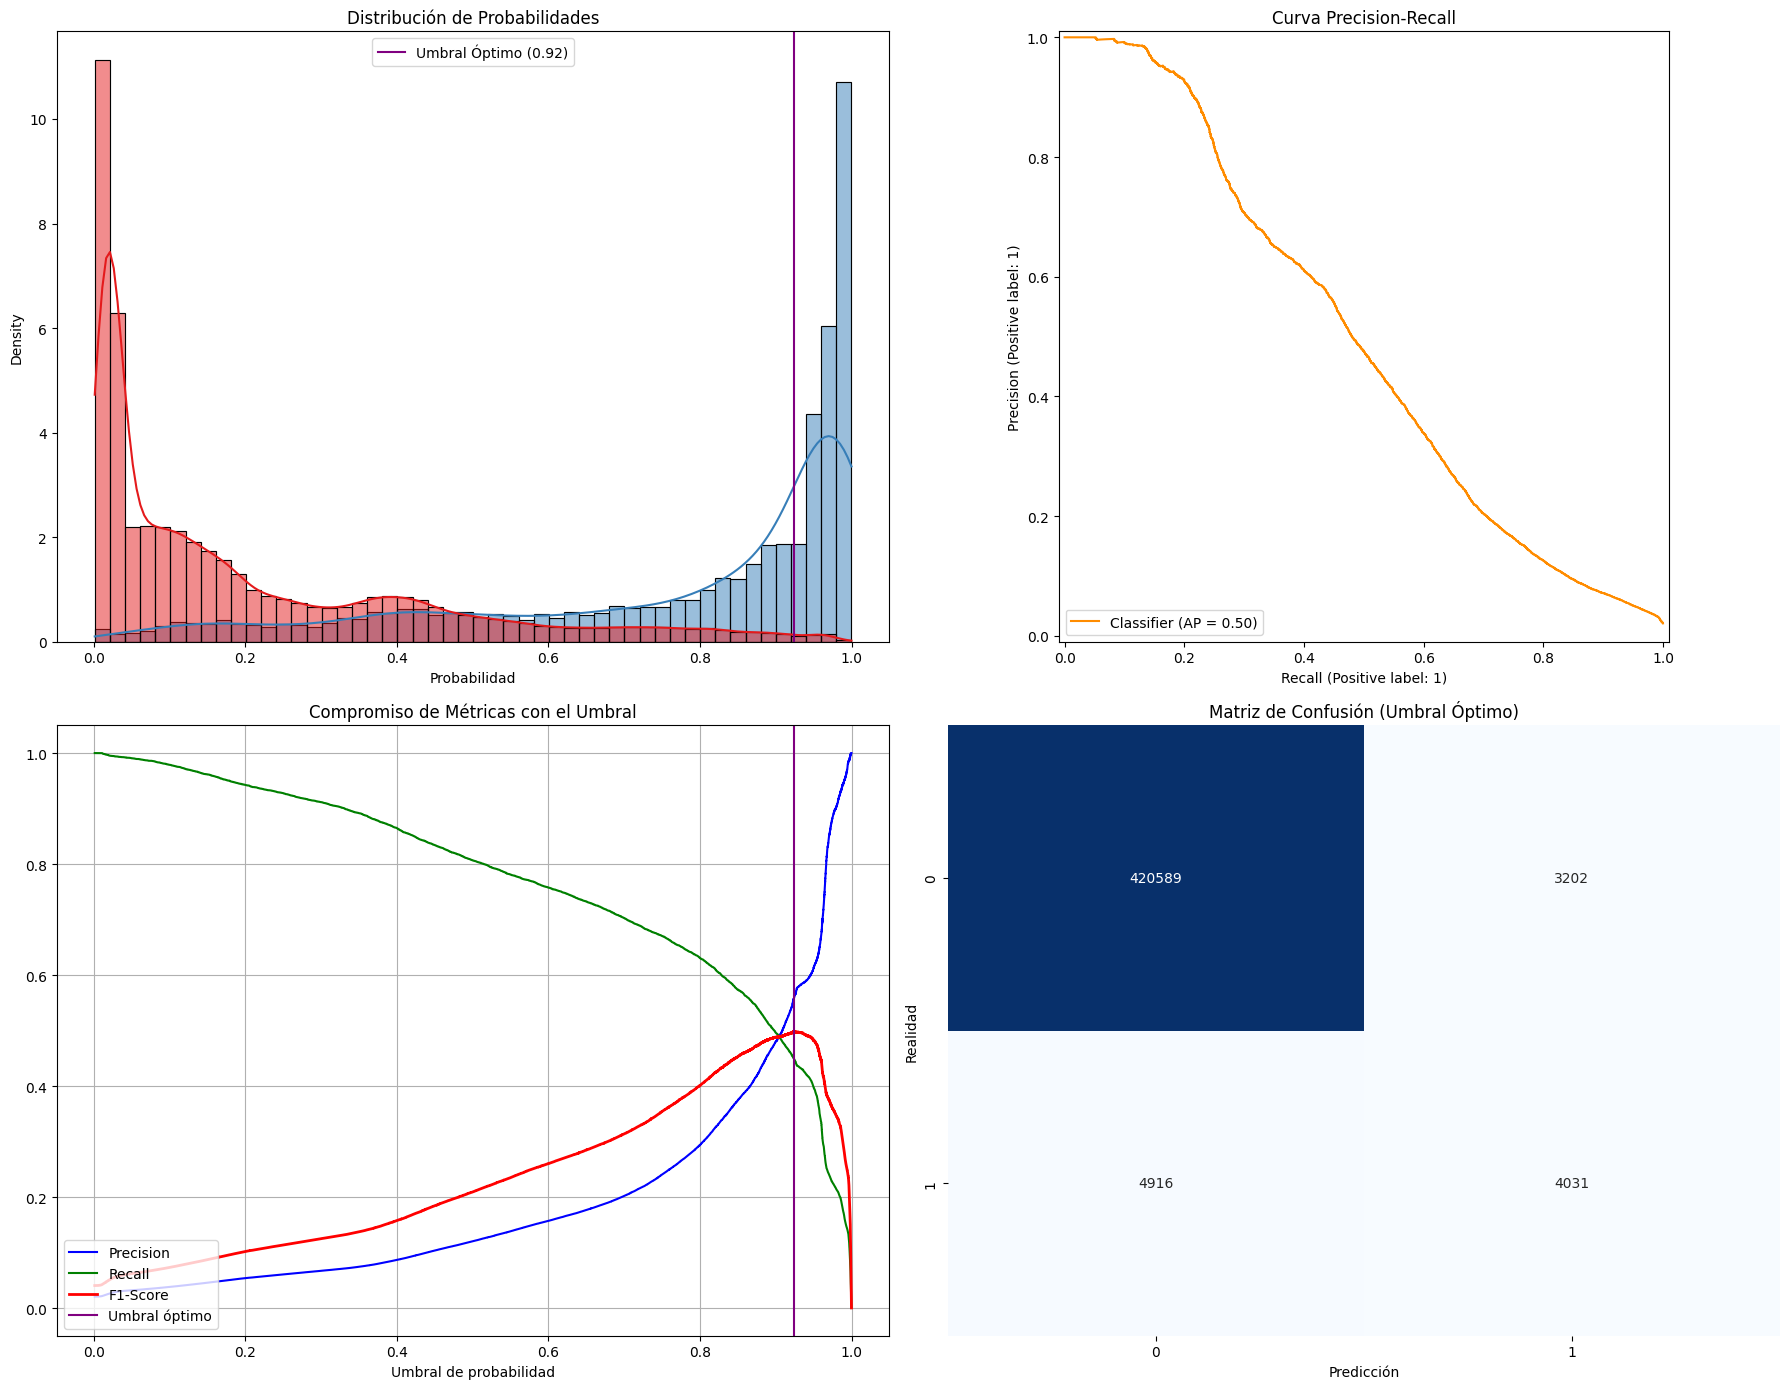

<Figure size 1000x800 with 0 Axes>

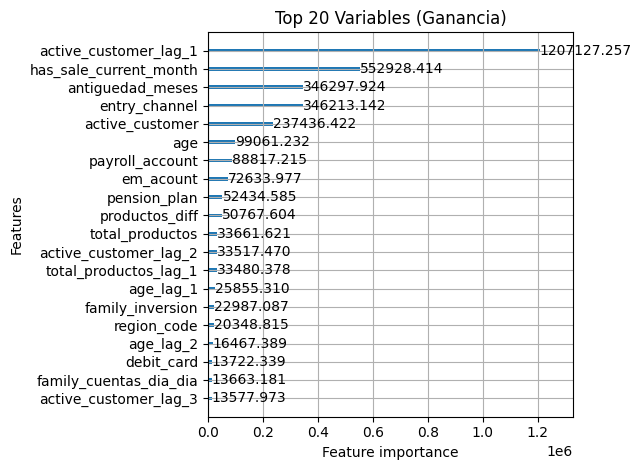

In [14]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, roc_auc_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Búsqueda de Umbral Óptimo
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
max_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_idx]

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Umbral óptimo que maximiza F1: {optimal_threshold:.4f} (F1: {f1_scores[max_f1_idx]:.4f})")

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print("\n--- Resultados con Umbral Óptimo ---")
print(classification_report(y_test, y_pred_optimal))

# 2. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A. Distribución de Probabilidades
df_probs = pd.DataFrame({'Probabilidad': y_proba, 'Venta_Real': y_test})
sns.histplot(data=df_probs, x='Probabilidad', hue='Venta_Real', bins=50, stat='density', common_norm=False, kde=True, palette='Set1', ax=axes[0,0])
axes[0,0].axvline(optimal_threshold, color='purple', linestyle='-', label=f'Umbral Óptimo ({optimal_threshold:.2f})')
axes[0,0].set_title('Distribución de Probabilidades')
axes[0,0].legend()

# B. Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, color='darkorange', ax=axes[0,1])
axes[0,1].set_title('Curva Precision-Recall')

# C. Compromiso Umbral vs Métricas
axes[1,0].plot(thresholds, precision[:-1], 'b-', label='Precision')
axes[1,0].plot(thresholds, recall[:-1], 'g-', label='Recall')
axes[1,0].plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score', linewidth=2)
axes[1,0].axvline(optimal_threshold, color='purple', linestyle='-', label='Umbral óptimo')
axes[1,0].set_title('Compromiso de Métricas con el Umbral')
axes[1,0].set_xlabel('Umbral de probabilidad')
axes[1,0].legend(loc='lower left')
axes[1,0].grid(True)

# D. Matriz de Confusión (Óptima)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión (Umbral Óptimo)')
axes[1,1].set_xlabel('Predicción')
axes[1,1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

# E. Importancia de Variables (Gráfico Independiente)
plt.figure(figsize=(10, 8))
lgb.plot_importance(clf_final, importance_type='gain', max_num_features=20, title='Top 20 Variables (Ganancia)')
plt.tight_layout()
plt.show()

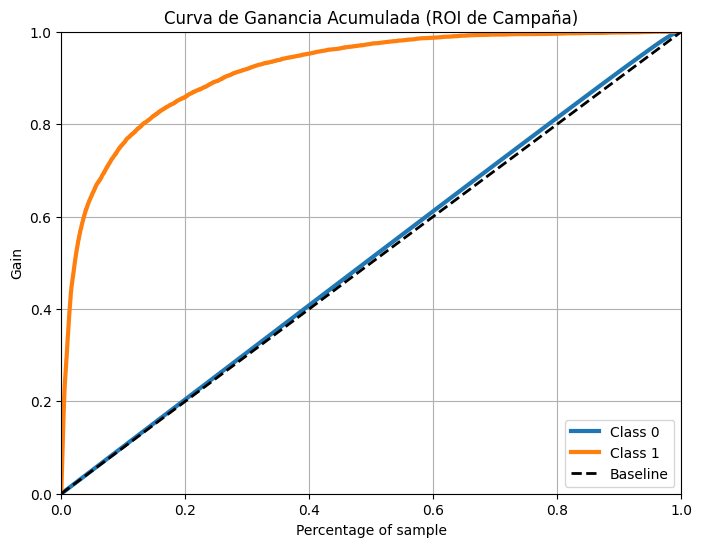

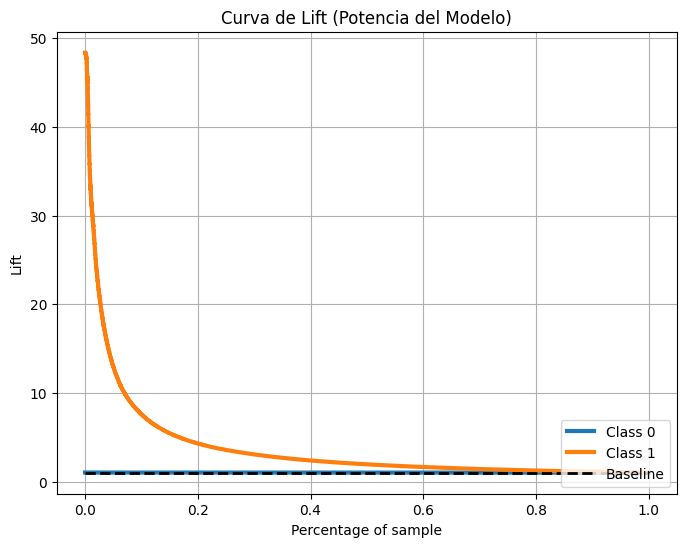

Calculando Curvas de Aprendizaje (esto puede tardar)...


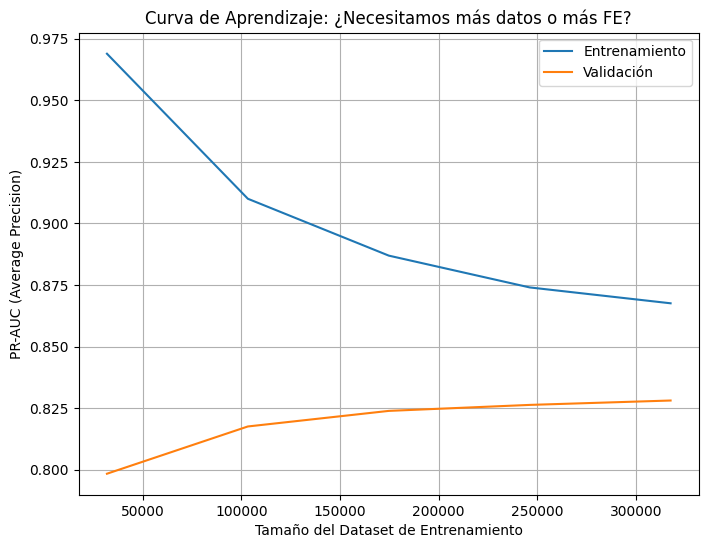

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
scipy.interp = np.interp 
import scikitplot as skplt # Si no la tienes: pip install scikit-plot
from sklearn.model_selection import learning_curve

# 1. CURVAS DE GAIN Y LIFT (Storytelling de Negocio)
# ---------------------------------------------------------
# Estas gráficas muestran cuántas veces es mejor el modelo que el azar
skplt.metrics.plot_cumulative_gain(y_test, clf_final.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Ganancia Acumulada (ROI de Campaña)')
plt.show()

skplt.metrics.plot_lift_curve(y_test, clf_final.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Lift (Potencia del Modelo)')
plt.show()


# 2. LEARNING CURVES (Potencial de mejora)
# ---------------------------------------------------------
# Nos dice si el modelo ha dejado de aprender con los datos actuales
print("Calculando Curvas de Aprendizaje (esto puede tardar)...")
train_sizes, train_scores, test_scores = learning_curve(
    clf_final, X_train_bal, y_train_bal, cv=3, scoring='average_precision',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Entrenamiento')
plt.plot(train_sizes, test_mean, label='Validación')
plt.title('Curva de Aprendizaje: ¿Necesitamos más datos o más FE?')
plt.xlabel('Tamaño del Dataset de Entrenamiento')
plt.ylabel('PR-AUC (Average Precision)')
plt.legend()
plt.grid(True)
plt.show()


# 3. CÁLCULO DE IV (Information Value) - Estándar Bancario
# ---------------------------------------------------------
def calculate_iv(df, feature, target):
    lst = []
    for i in range(df[feature].nunique()):
        val = list(df[feature].unique())[i]
        lst.append([val, 
                    df[(df[feature] == val) & (df[target] == 0)].count()[feature],
                    df[(df[feature] == val) & (df[target] == 1)].count()[feature]])
    
    data = pd.DataFrame(lst, columns=['Value', 'All_0', 'All_1'])
    data['Dist_0'] = data['All_0'] / data['All_0'].sum()
    data['Dist_1'] = data['All_1'] / data['All_1'].sum()
    data['WoE'] = np.log(data['Dist_1'] / data['Dist_0'])
    data['IV'] = (data['Dist_1'] - data['Dist_0'] + 1e-6) * (data['WoE'] + 1e-6)
    data = data.replace([np.inf, -np.inf], 0)
    return data['IV'].sum()

# Ejemplo con tu variable estrella
# iv_antiguedad = calculate_iv(df_train_balanced, 'antiguedad_meses', 'target_HasSale_next_month')
# print(f"Information Value de Antigüedad: {iv_antiguedad:.4f}")

In [16]:
def calculate_iv(df, feature, target):
    lst = []
    for i in range(df[feature].nunique()):
        val = list(df[feature].unique())[i]
        lst.append([val, 
                    df[(df[feature] == val) & (df[target] == 0)].count()[feature],
                    df[(df[feature] == val) & (df[target] == 1)].count()[feature]])
    
    data = pd.DataFrame(lst, columns=['Value', 'All_0', 'All_1'])
    data['Dist_0'] = data['All_0'] / data['All_0'].sum()
    data['Dist_1'] = data['All_1'] / data['All_1'].sum()
    data['WoE'] = np.log(data['Dist_1'] / data['Dist_0'])
    data['IV'] = (data['Dist_1'] - data['Dist_0'] + 1e-6) * (data['WoE'] + 1e-6)
    data = data.replace([np.inf, -np.inf], 0)
    return data['IV'].sum()


In [ ]:
iv_antiguedad = calculate_iv(df_train_balanced, 'antiguedad_meses', 'target_HasSale_next_month')
print(f"Information Value de Antigüedad: {iv_antiguedad:.4f}")
iv_productos_diff = calculate_iv(df_train_balanced, 'productos_diff', 'target_HasSale_next_month')
print(f"Information Value de Diferencia de productos contratados: {iv_productos_diff:.4f}")
iv_segment_upgrade = calculate_iv(df_train_balanced, 'segment_upgrade', 'target_HasSale_next_month')
print(f"Information Value de Aumento de segmento: {iv_segment_upgrade:.4f}")
iv_region_changed = calculate_iv(df_train_balanced, 'region_changed', 'target_HasSale_next_month')
print(f"Information Value de Cambio de provincia: {iv_region_changed:.4f}")
iv_age_diff = calculate_iv(df_train_balanced, 'age_diff', 'target_HasSale_next_month')
print(f"Information Value de Cambio de edad: {iv_age_diff:.4f}")
iv_salary_diff = calculate_iv(df_train_balanced, 'salary_diff', 'target_HasSale_next_month')
print(f"Information Value de Cambio de salario: {iv_salary_diff:.4f}")

Information Value de Antigüedad: 0.6757
Information Value de Diferencia de productos contratados: 0.8120
Information Value de Aumento de segmento: 0.0511
Information Value de Cambio de provincia: 0.0009
Information Value de Cambio de salario: 0.0502


c:\Users\j\Desktop\Joaquín\Clase\Master\VSC\TFM_06\penv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [26]:
iv_age_diff = calculate_iv(df_train_balanced, 'age_diff', 'target_HasSale_next_month')
print(f"Information Value de Cambio de edad: {iv_age_diff:.4f}")

Information Value de Cambio de edad: 0.0054


c:\Users\j\Desktop\Joaquín\Clase\Master\VSC\TFM_06\penv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 8.2 Modelo para familias contratadas

En esta segunda modelización, el foco se desplaza desde la compra agregada hacia la contratación por **familia de producto**.  
Esto permite una lectura más accionable para campañas segmentadas y recomendaciones comerciales a nivel intermedio.


In [54]:
from sklearn.utils import shuffle

train_cutoff = '2019-01'
test_month = '2019-02'

# División Temporal (Out-of-Time)
df_train = df_model_f2[df_model_f2['pk_partition'] <= pd.to_datetime(train_cutoff)]
X_test = df_model_f2[df_model_f2['pk_partition'] == pd.to_datetime(test_month)][features]
y_test = df_model_f2[df_model_f2['pk_partition'] == pd.to_datetime(test_month)][target_col]

# Undersampling solo en Train
df_minority = df_train[df_train[target_col] == 1]
df_majority = df_train[df_train[target_col] == 0]

ratio_neg_pos = 3
frac_reduccion = (len(df_minority) * ratio_neg_pos) / len(df_majority)

print("Realizando undersampling estratificado...")
df_majority_downsampled = df_majority.groupby(
    # ['segment', 'active_customer', 'region_code'], 
    ['segment', 'active_customer'],
    group_keys=False,
    observed=True 
).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))

df_train_balanced = shuffle(pd.concat([df_minority, df_majority_downsampled]), random_state=42)

X_train_bal = df_train_balanced[features]
y_train_bal = df_train_balanced[target_col]

Realizando undersampling estratificado...


C:\Users\j\AppData\Local\Temp\ipykernel_64812\3182120337.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))


In [55]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

clf_cuentas = lgb.LGBMClassifier(
    n_estimators=2000,           
    learning_rate=0.05,          
    max_depth=10,                
    min_child_samples=100,       
    class_weight='balanced',     
    random_state=42,
    n_jobs=-1
)

print("\nEntrenando modelo FINAL con Early Stopping...")
clf_cuentas.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)], 
    eval_metric='average_precision',           
    callbacks=[
        early_stopping(stopping_rounds=50, first_metric_only=True), 
        log_evaluation(50)                  
    ]
)

# Generar predicciones base
y_pred_base = clf_cuentas.predict(X_test)
y_proba = clf_cuentas.predict_proba(X_test)[:, 1]


Entrenando modelo FINAL con Early Stopping...
[LightGBM] [Info] Number of positive: 92147, number of negative: 276441
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2088
[LightGBM] [Info] Number of data points in the train set: 368588, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.328041	valid_0's binary_logloss: 0.381105
[100]	valid_0's average_precision: 0.373861	valid_0's binary_logloss: 0.352683
[150]	valid_0's average_precision: 0.383654	valid_0's binary_logloss: 0.344537
[200]	valid_0's average_precision: 0.386174	valid_0's binary_logloss: 0.341478
[250]	valid_0's a


ROC-AUC: 0.9174
Umbral óptimo que maximiza F1: 0.9141 (F1: 0.4285)

--- Resultados con Umbral Óptimo ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    425290
           1       0.45      0.41      0.43      7448

    accuracy                           0.98    432738
   macro avg       0.72      0.70      0.71    432738
weighted avg       0.98      0.98      0.98    432738



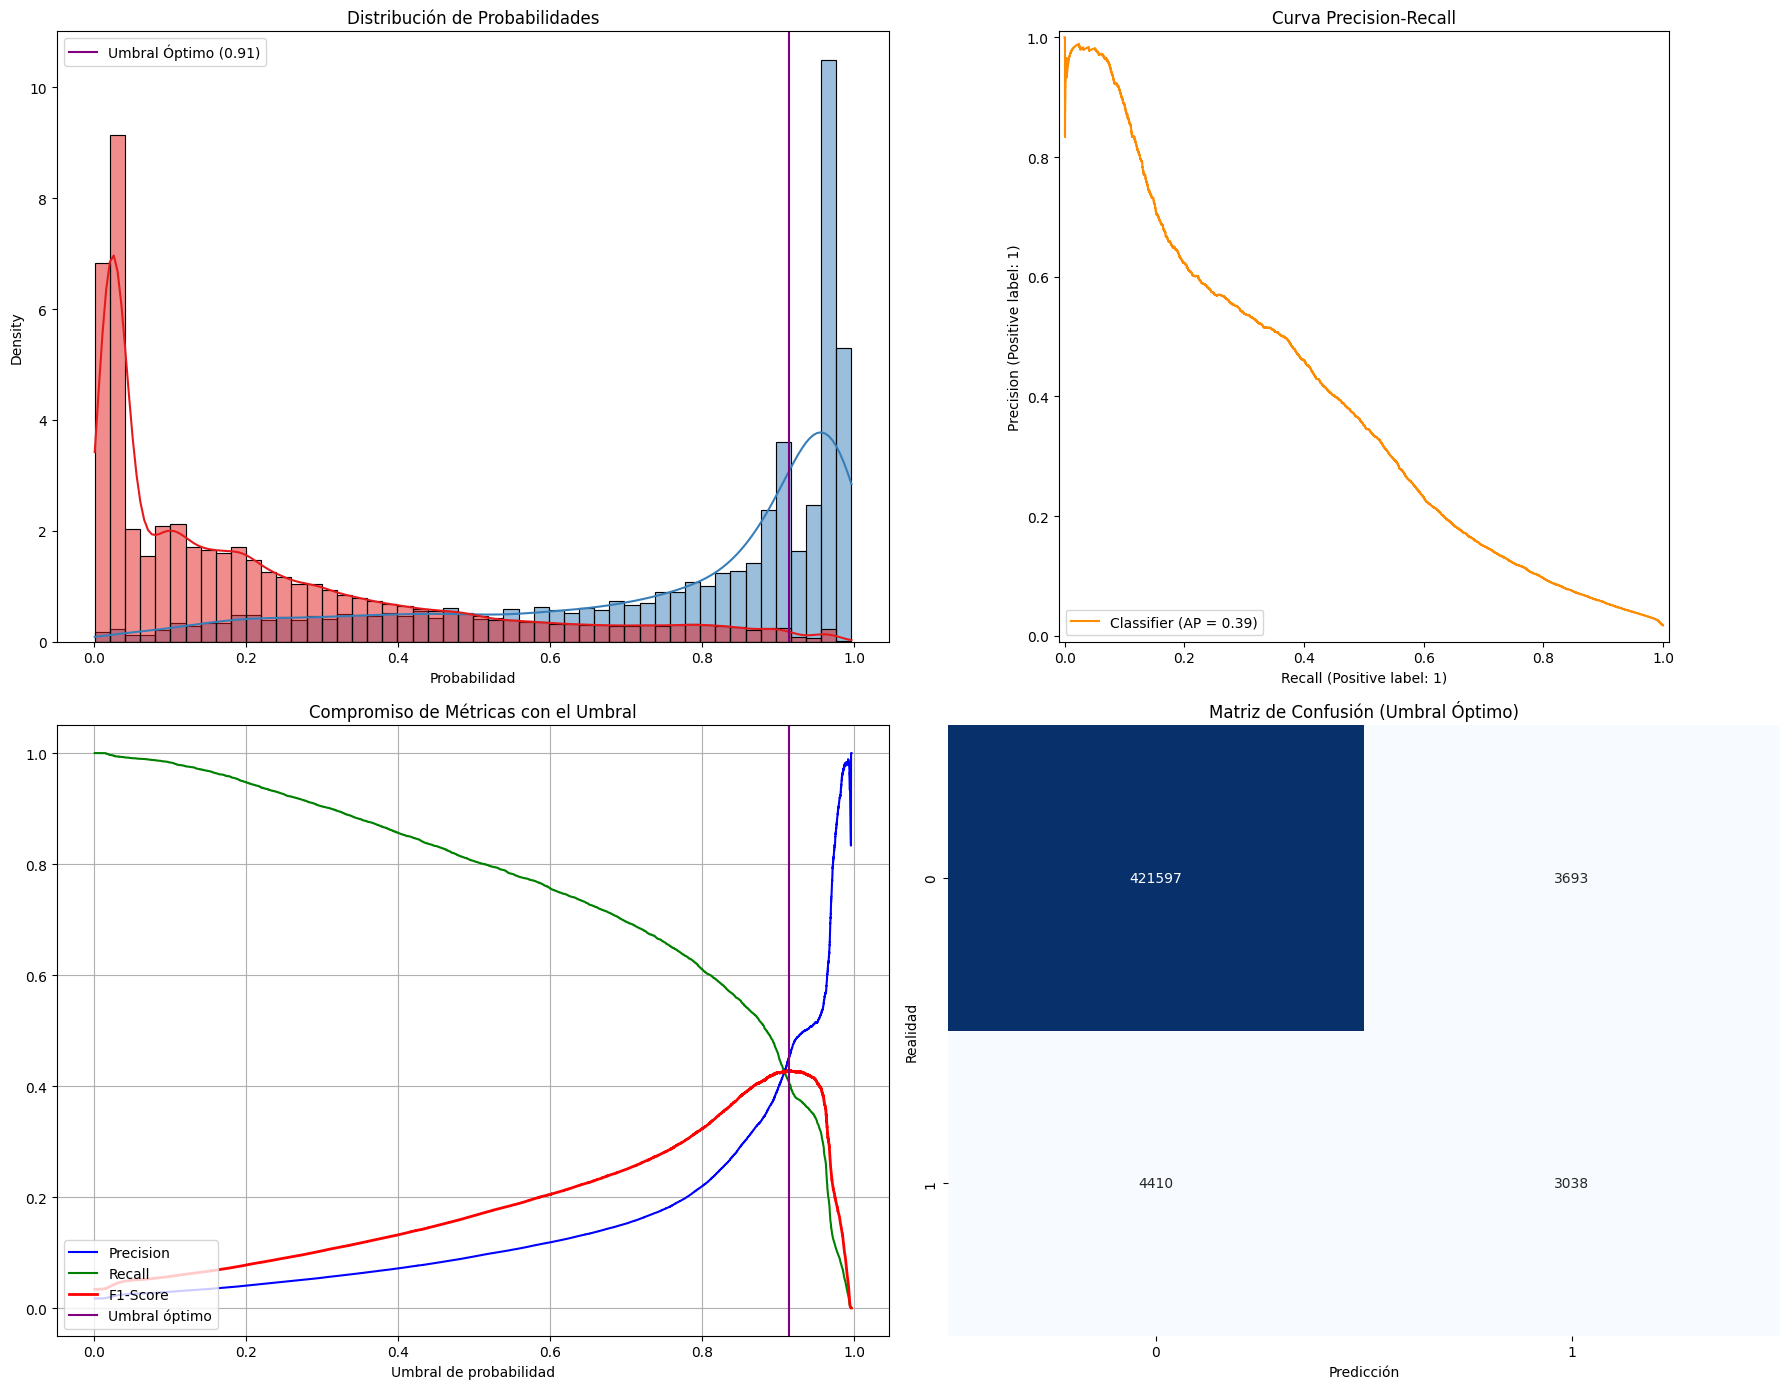

<Figure size 1000x800 with 0 Axes>

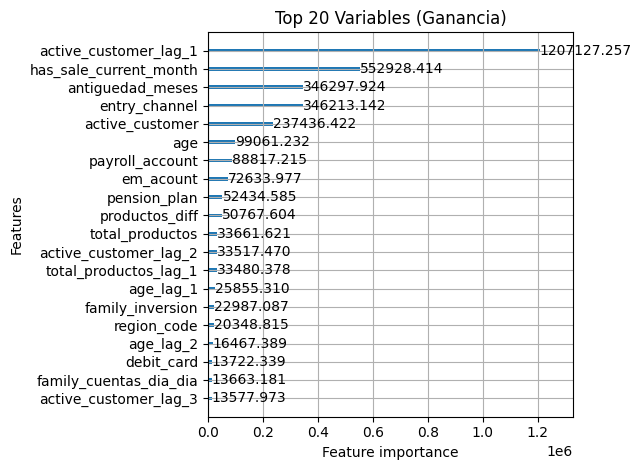

In [56]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, roc_auc_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Búsqueda de Umbral Óptimo
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
max_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_idx]

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Umbral óptimo que maximiza F1: {optimal_threshold:.4f} (F1: {f1_scores[max_f1_idx]:.4f})")

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print("\n--- Resultados con Umbral Óptimo ---")
print(classification_report(y_test, y_pred_optimal))

# 2. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A. Distribución de Probabilidades
df_probs = pd.DataFrame({'Probabilidad': y_proba, 'Venta_Real': y_test})
sns.histplot(data=df_probs, x='Probabilidad', hue='Venta_Real', bins=50, stat='density', common_norm=False, kde=True, palette='Set1', ax=axes[0,0])
axes[0,0].axvline(optimal_threshold, color='purple', linestyle='-', label=f'Umbral Óptimo ({optimal_threshold:.2f})')
axes[0,0].set_title('Distribución de Probabilidades')
axes[0,0].legend()

# B. Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, color='darkorange', ax=axes[0,1])
axes[0,1].set_title('Curva Precision-Recall')

# C. Compromiso Umbral vs Métricas
axes[1,0].plot(thresholds, precision[:-1], 'b-', label='Precision')
axes[1,0].plot(thresholds, recall[:-1], 'g-', label='Recall')
axes[1,0].plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score', linewidth=2)
axes[1,0].axvline(optimal_threshold, color='purple', linestyle='-', label='Umbral óptimo')
axes[1,0].set_title('Compromiso de Métricas con el Umbral')
axes[1,0].set_xlabel('Umbral de probabilidad')
axes[1,0].legend(loc='lower left')
axes[1,0].grid(True)

# D. Matriz de Confusión (Óptima)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión (Umbral Óptimo)')
axes[1,1].set_xlabel('Predicción')
axes[1,1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

# E. Importancia de Variables (Gráfico Independiente)
plt.figure(figsize=(10, 8))
lgb.plot_importance(clf_final, importance_type='gain', max_num_features=20, title='Top 20 Variables (Ganancia)')
plt.tight_layout()
plt.show()

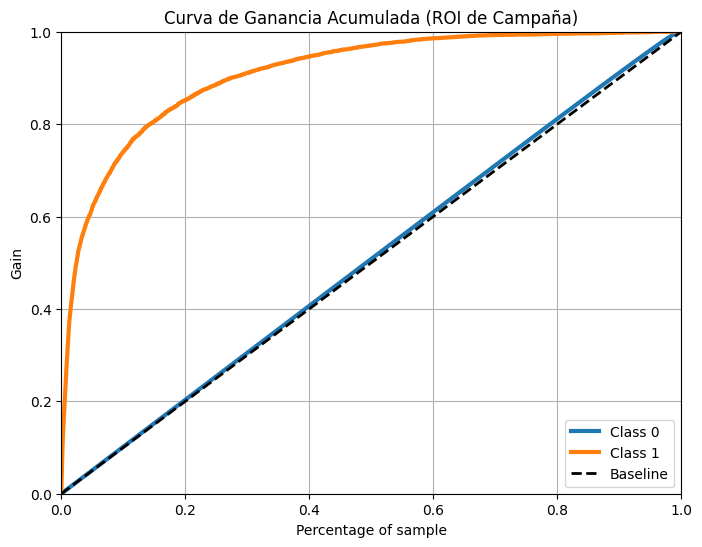

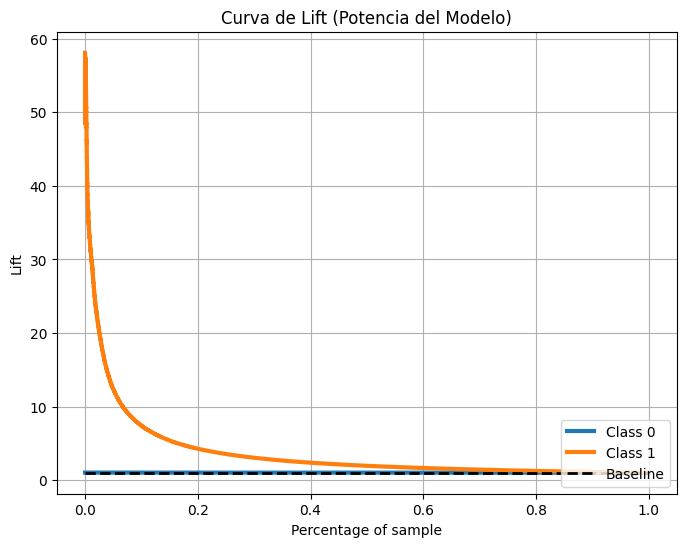

Calculando Curvas de Aprendizaje (esto puede tardar)...


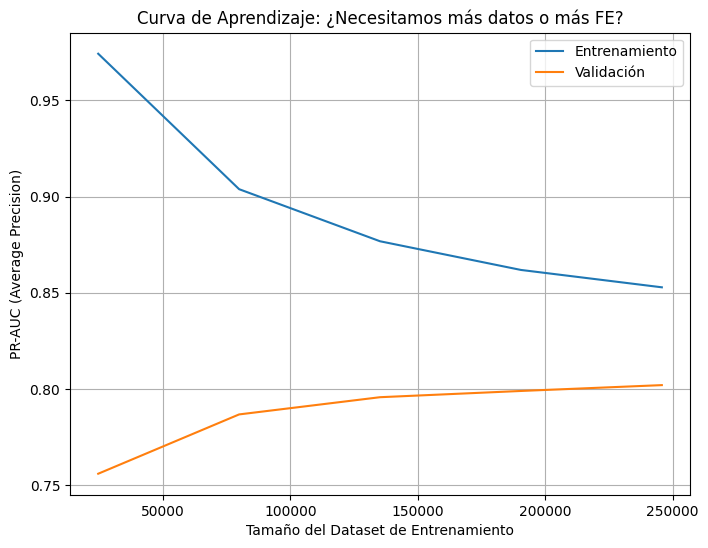

Information Value de Antigüedad: 0.7657
Information Value de Diferencia de productos contratados: 0.1036
Information Value de Aumento de segmento: 0.0455
Information Value de Cambio de salario: 0.0541


c:\Users\j\Desktop\Joaquín\Clase\Master\VSC\TFM_06\penv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
scipy.interp = np.interp 
import scikitplot as skplt # Si no la tienes: pip install scikit-plot
from sklearn.model_selection import learning_curve

# 1. CURVAS DE GAIN Y LIFT (Storytelling de Negocio)
# ---------------------------------------------------------
# Estas gráficas muestran cuántas veces es mejor el modelo que el azar
skplt.metrics.plot_cumulative_gain(y_test, clf_cuentas.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Ganancia Acumulada (ROI de Campaña)')
plt.show()

skplt.metrics.plot_lift_curve(y_test, clf_cuentas.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Lift (Potencia del Modelo)')
plt.show()


# 2. LEARNING CURVES (Potencial de mejora)
# ---------------------------------------------------------
# Nos dice si el modelo ha dejado de aprender con los datos actuales
print("Calculando Curvas de Aprendizaje (esto puede tardar)...")
train_sizes, train_scores, test_scores = learning_curve(
    clf_cuentas, X_train_bal, y_train_bal, cv=3, scoring='average_precision',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Entrenamiento')
plt.plot(train_sizes, test_mean, label='Validación')
plt.title('Curva de Aprendizaje: ¿Necesitamos más datos o más FE?')
plt.xlabel('Tamaño del Dataset de Entrenamiento')
plt.ylabel('PR-AUC (Average Precision)')
plt.legend()
plt.grid(True)
plt.show()

iv_antiguedad = calculate_iv(df_train_balanced, 'antiguedad_meses', target_col)
print(f"Information Value de Antigüedad: {iv_antiguedad:.4f}")
iv_productos_diff = calculate_iv(df_train_balanced, 'productos_diff', target_col)
print(f"Information Value de Diferencia de productos contratados: {iv_productos_diff:.4f}")
iv_segment_upgrade = calculate_iv(df_train_balanced, 'segment_upgrade', target_col)
print(f"Information Value de Aumento de segmento: {iv_segment_upgrade:.4f}")
iv_salary_diff = calculate_iv(df_train_balanced, 'salary_diff', target_col)
print(f"Information Value de Cambio de salario: {iv_salary_diff:.4f}")

### 8.3 Modelo para productos concretos

El tercer modelo aborda la predicción de contratación de **productos específicos**.  
Se trata del caso más exigente desde el punto de vista analítico, ya que combina mayor granularidad con una señal objetivo más escasa.


In [6]:
from sklearn.utils import shuffle

train_cutoff = '2019-01'
test_month = '2019-02'

# División Temporal (Out-of-Time)
df_train = df_model_f3[df_model_f3['pk_partition'] <= pd.to_datetime(train_cutoff)]
X_test = df_model_f3[df_model_f3['pk_partition'] == pd.to_datetime(test_month)][features]
y_test = df_model_f3[df_model_f3['pk_partition'] == pd.to_datetime(test_month)][target_col]

# Undersampling solo en Train
df_minority = df_train[df_train[target_col] == 1]
df_majority = df_train[df_train[target_col] == 0]

ratio_neg_pos = 3
frac_reduccion = (len(df_minority) * ratio_neg_pos) / len(df_majority)

print("Realizando undersampling estratificado...")
df_majority_downsampled = df_majority.groupby(
    # ['segment', 'active_customer', 'region_code'], 
    ['segment', 'active_customer'],
    group_keys=False,
    observed=True 
).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))

df_train_balanced = shuffle(pd.concat([df_minority, df_majority_downsampled]), random_state=42)

X_train_bal = df_train_balanced[features]
y_train_bal = df_train_balanced[target_col]

Realizando undersampling estratificado...


C:\Users\j\AppData\Local\Temp\ipykernel_23796\4144741669.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.sample(frac=frac_reduccion, random_state=42))


In [7]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

clf_producto = lgb.LGBMClassifier(
    n_estimators=2000,           
    learning_rate=0.05,          
    max_depth=10,                
    min_child_samples=100,       
    class_weight='balanced',     
    random_state=42,
    n_jobs=-1
)

print("\nEntrenando modelo FINAL con Early Stopping...")
clf_producto.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)], 
    eval_metric='average_precision',           
    callbacks=[
        early_stopping(stopping_rounds=50, first_metric_only=True), 
        log_evaluation(50)                  
    ]
)

# Generar predicciones base
y_pred_base = clf_producto.predict(X_test)
y_proba = clf_producto.predict_proba(X_test)[:, 1]


Entrenando modelo FINAL con Early Stopping...
[LightGBM] [Info] Number of positive: 30875, number of negative: 92625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 123500, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.105508	valid_0's binary_logloss: 0.362696
[100]	valid_0's average_precision: 0.137544	valid_0's binary_logloss: 0.339219
[150]	valid_0's average_precision: 0.140449	valid_0's binary_logloss: 0.330388
[200]	valid_0's average_precision: 0.141857	valid_0's binary_logloss: 0.325915
[250]	valid_0's av


ROC-AUC: 0.9324
Umbral óptimo que maximiza F1: 0.9333 (F1: 0.2146)

--- Resultados con Umbral Óptimo ---
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    430218
         1.0       0.16      0.31      0.21      2520

    accuracy                           0.99    432738
   macro avg       0.58      0.65      0.60    432738
weighted avg       0.99      0.99      0.99    432738



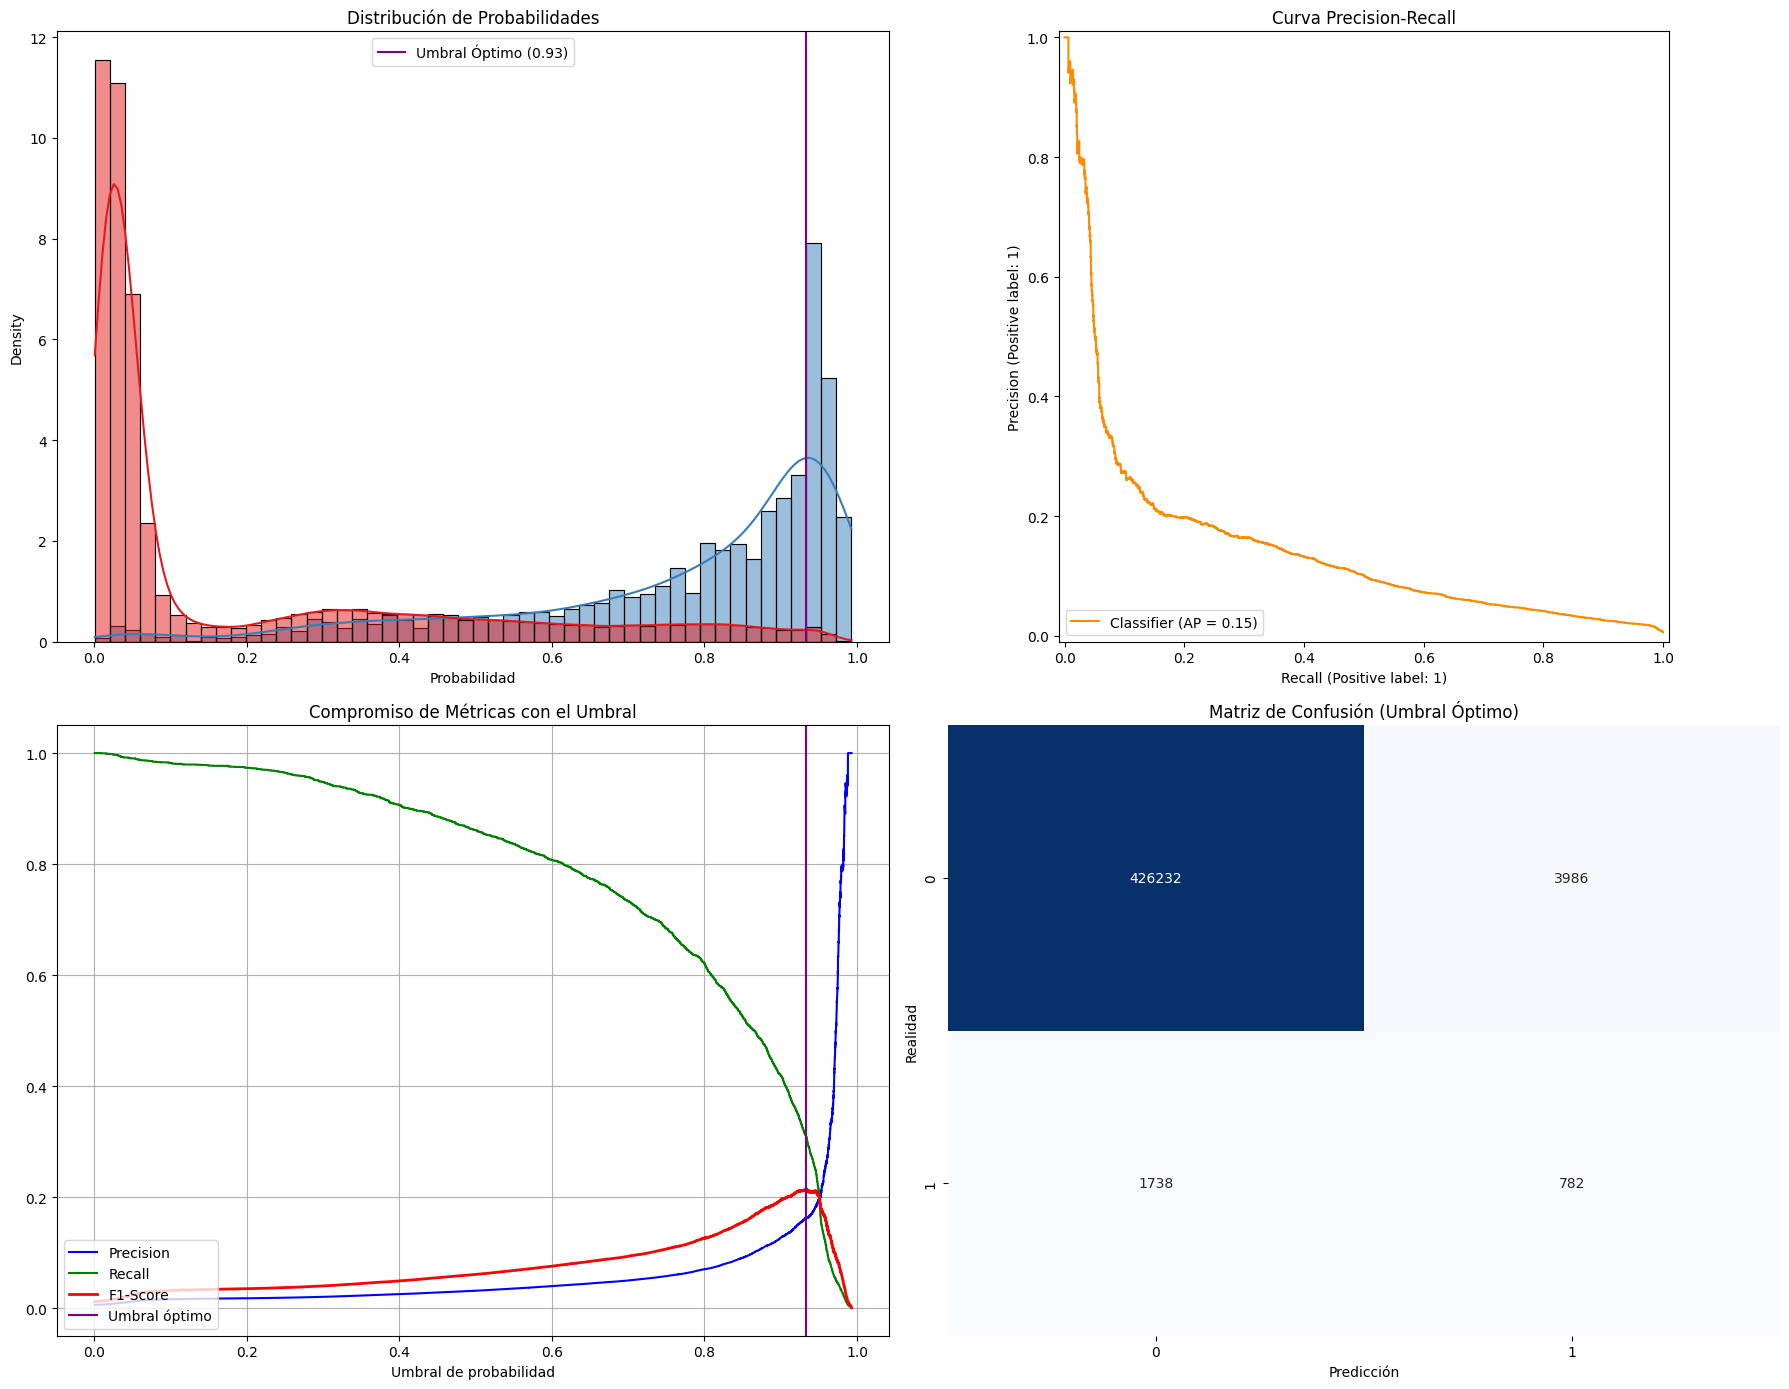

<Figure size 1000x800 with 0 Axes>

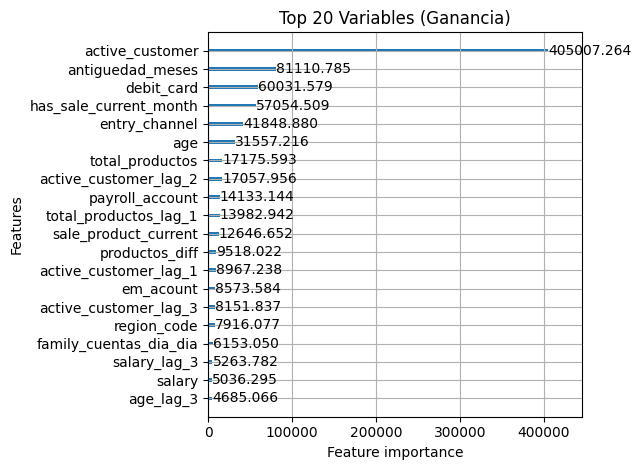

In [8]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, roc_auc_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Búsqueda de Umbral Óptimo
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
max_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_idx]

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Umbral óptimo que maximiza F1: {optimal_threshold:.4f} (F1: {f1_scores[max_f1_idx]:.4f})")

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print("\n--- Resultados con Umbral Óptimo ---")
print(classification_report(y_test, y_pred_optimal))

# 2. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A. Distribución de Probabilidades
df_probs = pd.DataFrame({'Probabilidad': y_proba, 'Venta_Real': y_test})
sns.histplot(data=df_probs, x='Probabilidad', hue='Venta_Real', bins=50, stat='density', common_norm=False, kde=True, palette='Set1', ax=axes[0,0])
axes[0,0].axvline(optimal_threshold, color='purple', linestyle='-', label=f'Umbral Óptimo ({optimal_threshold:.2f})')
axes[0,0].set_title('Distribución de Probabilidades')
axes[0,0].legend()

# B. Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, color='darkorange', ax=axes[0,1])
axes[0,1].set_title('Curva Precision-Recall')

# C. Compromiso Umbral vs Métricas
axes[1,0].plot(thresholds, precision[:-1], 'b-', label='Precision')
axes[1,0].plot(thresholds, recall[:-1], 'g-', label='Recall')
axes[1,0].plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score', linewidth=2)
axes[1,0].axvline(optimal_threshold, color='purple', linestyle='-', label='Umbral óptimo')
axes[1,0].set_title('Compromiso de Métricas con el Umbral')
axes[1,0].set_xlabel('Umbral de probabilidad')
axes[1,0].legend(loc='lower left')
axes[1,0].grid(True)

# D. Matriz de Confusión (Óptima)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión (Umbral Óptimo)')
axes[1,1].set_xlabel('Predicción')
axes[1,1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

# E. Importancia de Variables (Gráfico Independiente)
plt.figure(figsize=(10, 8))
lgb.plot_importance(clf_producto, importance_type='gain', max_num_features=20, title='Top 20 Variables (Ganancia)')
plt.tight_layout()
plt.show()

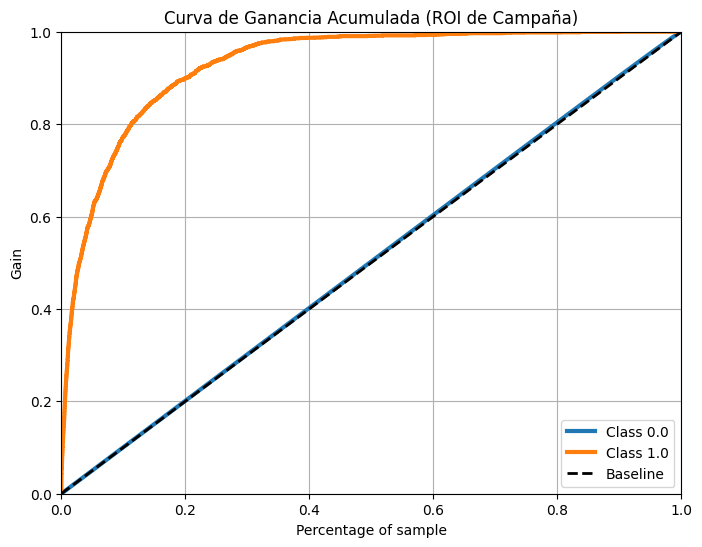

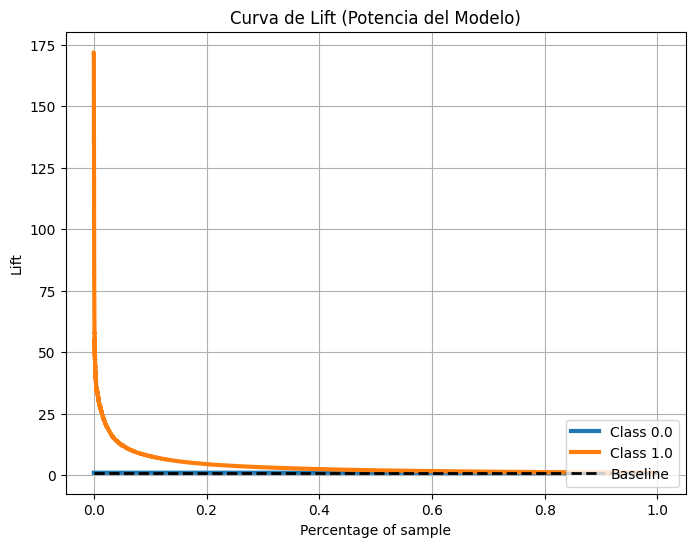

Calculando Curvas de Aprendizaje (esto puede tardar)...


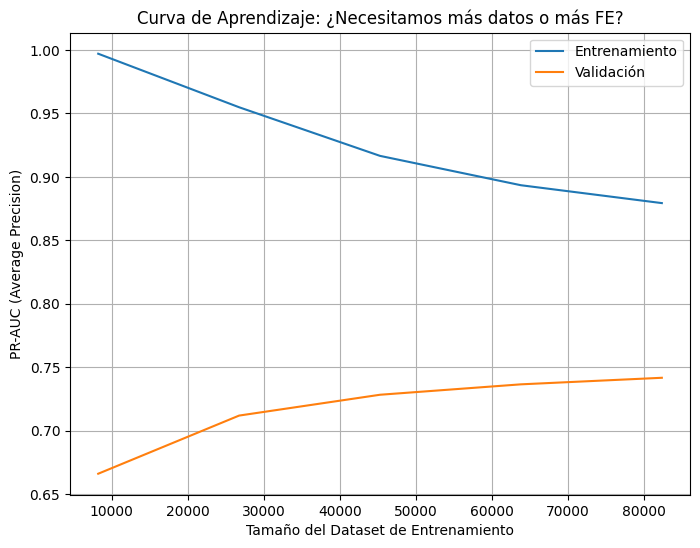

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
scipy.interp = np.interp 
import scikitplot as skplt # Si no la tienes: pip install scikit-plot
from sklearn.model_selection import learning_curve

# 1. CURVAS DE GAIN Y LIFT (Storytelling de Negocio)
# ---------------------------------------------------------
# Estas gráficas muestran cuántas veces es mejor el modelo que el azar
skplt.metrics.plot_cumulative_gain(y_test, clf_producto.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Ganancia Acumulada (ROI de Campaña)')
plt.show()

skplt.metrics.plot_lift_curve(y_test, clf_producto.predict_proba(X_test), figsize=(8,6))
plt.title('Curva de Lift (Potencia del Modelo)')
plt.show()


# 2. LEARNING CURVES (Potencial de mejora)
# ---------------------------------------------------------
# Nos dice si el modelo ha dejado de aprender con los datos actuales
print("Calculando Curvas de Aprendizaje (esto puede tardar)...")
train_sizes, train_scores, test_scores = learning_curve(
    clf_producto, X_train_bal, y_train_bal, cv=3, scoring='average_precision',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Entrenamiento')
plt.plot(train_sizes, test_mean, label='Validación')
plt.title('Curva de Aprendizaje: ¿Necesitamos más datos o más FE?')
plt.xlabel('Tamaño del Dataset de Entrenamiento')
plt.ylabel('PR-AUC (Average Precision)')
plt.legend()
plt.grid(True)
plt.show()

# iv_antiguedad = calculate_iv(df_train_balanced, 'antiguedad_meses', target_col)
# print(f"Information Value de Antigüedad: {iv_antiguedad:.4f}")
# iv_productos_diff = calculate_iv(df_train_balanced, 'productos_diff', target_col)
# print(f"Information Value de Diferencia de productos contratados: {iv_productos_diff:.4f}")
# iv_segment_upgrade = calculate_iv(df_train_balanced, 'segment_upgrade', target_col)
# print(f"Information Value de Aumento de segmento: {iv_segment_upgrade:.4f}")
# iv_salary_diff = calculate_iv(df_train_balanced, 'salary_diff', target_col)
# print(f"Information Value de Cambio de salario: {iv_salary_diff:.4f}")

## 9. Lectura analítica final

A modo de cierre, este notebook deja construida una base metodológica completa para la predicción de compra en easyMoney:

- se integran y limpian múltiples fuentes,
- se genera un dataset analítico temporal a nivel cliente-mes,
- se crean variables explicativas con enfoque secuencial,
- y se entrenan modelos con validación temporal y métricas útiles para negocio.

Desde la perspectiva del TFM, esta parte demuestra que los datos históricos del cliente no solo permiten describir su comportamiento, sino también **anticipar futuras decisiones de contratación**, abriendo la puerta a estrategias de segmentación avanzada, priorización comercial y recomendación de productos.
